In [1]:
!pip install rioxarray tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Importar librerías
import rioxarray as rxr
import xarray as xr
import numpy as np
import pandas as pd
import glob
import os
from scipy.stats import gamma, norm
from tqdm import tqdm
import shutil

# Cambia esta ruta a donde tienes tus archivos en Drive
ruta_tiffs = '/content/drive/MyDrive/CHIRPS_UY/*.tif'

# Ruta Sofi
#ruta_tiffs = '/content/drive/MyDrive/CHIRPS_UY/CHIRPS_UY/*.tif'

# Listar y ordenar archivos
archivos = sorted(glob.glob(ruta_tiffs))
print(f"{len(archivos)} archivos encontrados.")

# Extraer fechas desde nombres (ejemplo: chirps_YYYYMM.tif)
fechas = [pd.to_datetime(os.path.basename(f)[7:13], format="%Y%m") for f in archivos]

# Cargar y apilar los TIFFs en un DataArray con dimensión 'time'
print("Cargando archivos...")
stack = xr.concat(
    [rxr.open_rasterio(f, masked=True).squeeze(drop=True) for f in tqdm(archivos)],
    dim='time'
)
stack['time'] = fechas
stack.rio.write_crs("EPSG:4326", inplace=True)  # ajusta CRS si es necesario

# Función para calcular SPI corregida
def calcular_spi(precip, escala):
    """Calcula SPI para un DataArray 3D (time, y, x) en escala de meses indicada."""
    roll = precip.rolling(time=escala, min_periods=escala).sum()

    def _pixel_spi(ts):
        vals = np.asarray(ts)  # Cambio aquí, ts ya es ndarray
        spi_vals = np.full_like(vals, np.nan, dtype=np.float64)
        ok = ~np.isnan(vals)
        if np.sum(ok) < 24:  # mínimo de datos para buen ajuste
            return spi_vals
        try:
            params = gamma.fit(vals[ok], floc=0)
            cdf = gamma.cdf(vals[ok], *params)
            spi_vals[ok] = norm.ppf(cdf)
        except Exception:
            pass  # mantener NaN si falla
        return spi_vals

    spi = xr.apply_ufunc(
        _pixel_spi, roll,
        input_core_dims=[['time']],
        output_core_dims=[['time']],
        vectorize=True,
        dask='parallelized',
        output_dtypes=[float]
    )
    return spi

# Crear carpeta para resultados si no existe
output_folder = '/content/drive/MyDrive/resultados_spi'

#Carpeta Sofi
#output_folder = '/content/drive/MyDrive/resultados_spi'


if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Calcular y guardar SPI para cada escala
escalas = [1, 3, 6, 12]

for escala in escalas:
    print(f"\nCalculando SPI-{escala} meses...")
    spi = calcular_spi(stack, escala)
    spi = spi.assign_coords(time=stack.time)
    spi.name = f"SPI_{escala}"
    spi.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=True)
    spi.rio.write_crs("EPSG:4326", inplace=True)

    # Ordenar dimensiones para que rioxarray acepte guardar
    spi = spi.transpose('time', 'y', 'x')

    nombre_archivo = f"spi_{escala}m.tif"
    ruta_salida = os.path.join(output_folder, nombre_archivo)

    print(f"Guardando archivo: {ruta_salida}")
    spi.rio.to_raster(ruta_salida)

print("\n¡Proceso terminado! Los archivos SPI están guardados en tu Google Drive.")

360 archivos encontrados.
Cargando archivos...


100%|██████████| 360/360 [00:07<00:00, 50.71it/s]



Calculando SPI-1 meses...
Guardando archivo: /content/drive/MyDrive/resultados_spi/spi_1m.tif

Calculando SPI-3 meses...
Guardando archivo: /content/drive/MyDrive/resultados_spi/spi_3m.tif

Calculando SPI-6 meses...
Guardando archivo: /content/drive/MyDrive/resultados_spi/spi_6m.tif

Calculando SPI-12 meses...
Guardando archivo: /content/drive/MyDrive/resultados_spi/spi_12m.tif

¡Proceso terminado! Los archivos SPI están guardados en tu Google Drive.


In [7]:
!pip install geopandas rioxarray rasterio matplotlib --quiet

In [8]:
# === 3. IMPORTAR LIBRERÍAS ===
import rioxarray as rxr
import matplotlib.pyplot as plt
import pandas as pd
import os
from matplotlib.colors import LinearSegmentedColormap

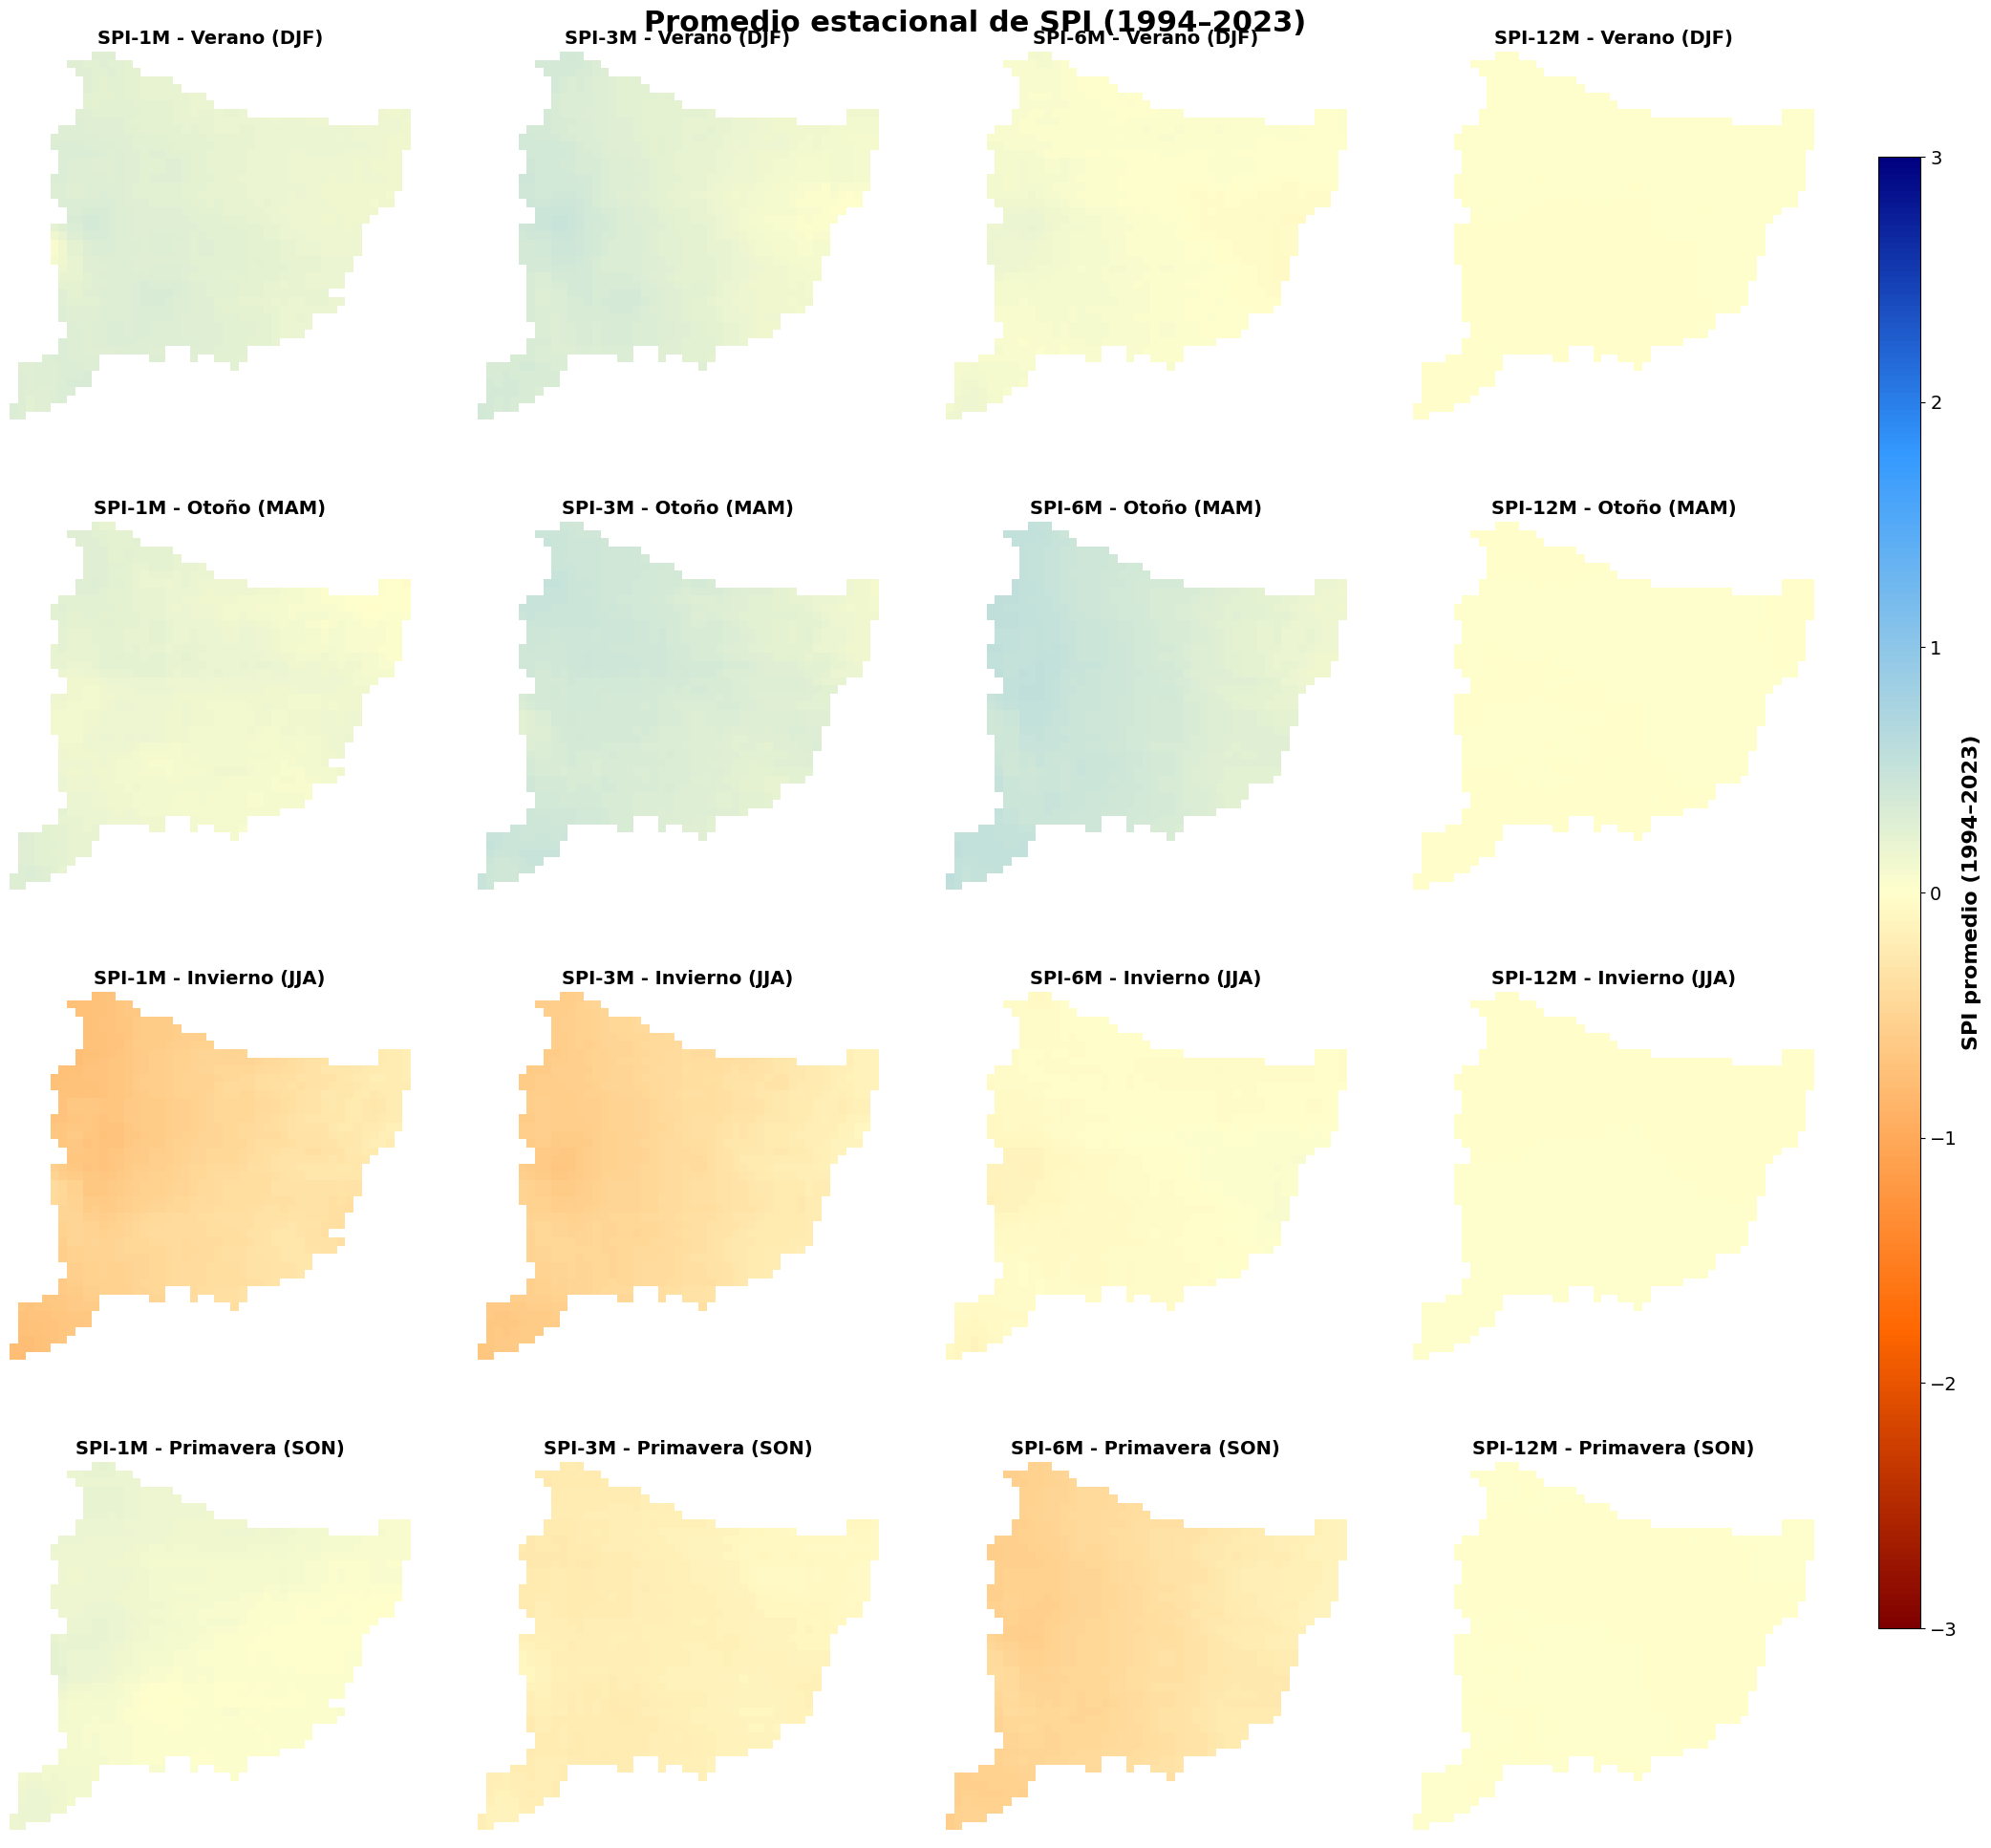

In [9]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr
from matplotlib.colors import LinearSegmentedColormap

# Parámetros comunes de rango SPI
spi_vmin = -3
spi_vmax = 3

# Colormap común
colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),  # sequía extrema (rojo oscuro)
        (0.2, "#ff6600"),  # sequía moderada (naranja)
        (0.5, "#ffffcc"),  # normal (beige claro)
        (0.8, "#3399ff"),  # húmedo moderado (celeste)
        (1.0, "#000080")   # húmedo extremo (azul oscuro)
    ]
)

# Ruta a archivos raster
ruta_rasters = '/content/drive/MyDrive/resultados_spi'

# Carga de rasters
rasters = {
    'SPI-1M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_1m.tif'), masked=True).squeeze(),
    'SPI-3M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_3m.tif'), masked=True).squeeze(),
    'SPI-6M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_6m.tif'), masked=True).squeeze(),
    'SPI-12M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_12m.tif'), masked=True).squeeze()
}

# Fechas asociadas a las bandas (360 meses desde 1994-01 a 2023-12)
fechas = pd.date_range(start="1994-01-01", periods=rasters['SPI-1M'].shape[0], freq="MS")

# Diccionario para agrupar estaciones
estaciones = {
    "Verano (DJF)": [12, 1, 2],
    "Otoño (MAM)": [3, 4, 5],
    "Invierno (JJA)": [6, 7, 8],
    "Primavera (SON)": [9, 10, 11]
}

# Calcular promedios estacionales
promedios_estacionales = {est: {} for est in estaciones.keys()}
for nombre_spi, data in rasters.items():
    for estacion, meses in estaciones.items():
        idx = [i for i, f in enumerate(fechas) if f.month in meses]
        data_est = data.isel(band=idx)
        promedios_estacionales[estacion][nombre_spi] = data_est.mean(dim="band")

# === Graficar todas las estaciones en un mismo "panel grande" ===
fig, axs = plt.subplots(len(estaciones), 4, figsize=(22, 22), constrained_layout=False)

# Para ir guardando el último "im" y usarlo en la colorbar
im = None

for row, (estacion, valores_spi) in enumerate(promedios_estacionales.items()):
    for col, (spi, data) in enumerate(valores_spi.items()):
        ax = axs[row, col]
        im = ax.imshow(data, cmap=colores_spi, vmin=spi_vmin, vmax=spi_vmax)
        ax.set_title(f"{spi} - {estacion}", fontsize=14, fontweight="bold")
        ax.axis("off")

# Crear UNA sola barra de colores para todos
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="vertical")
cbar.set_label("SPI promedio (1994–2023)", fontsize=16, fontweight="bold")
cbar.ax.tick_params(labelsize=14)

# Título general
fig.suptitle("Promedio estacional de SPI (1994–2023)", fontsize=22, fontweight="bold", y=0.92)

# Ajustar márgenes
plt.subplots_adjust(left=0.03, right=0.91, top=0.90, bottom=0.05, wspace=0.05, hspace=0.25)
plt.show()

/tmp/ipython-input-3809036491.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


✅ Figura guardada: /content/drive/MyDrive/figuras_spi_estacionales/SPI_promedio_Verano_DJF.png


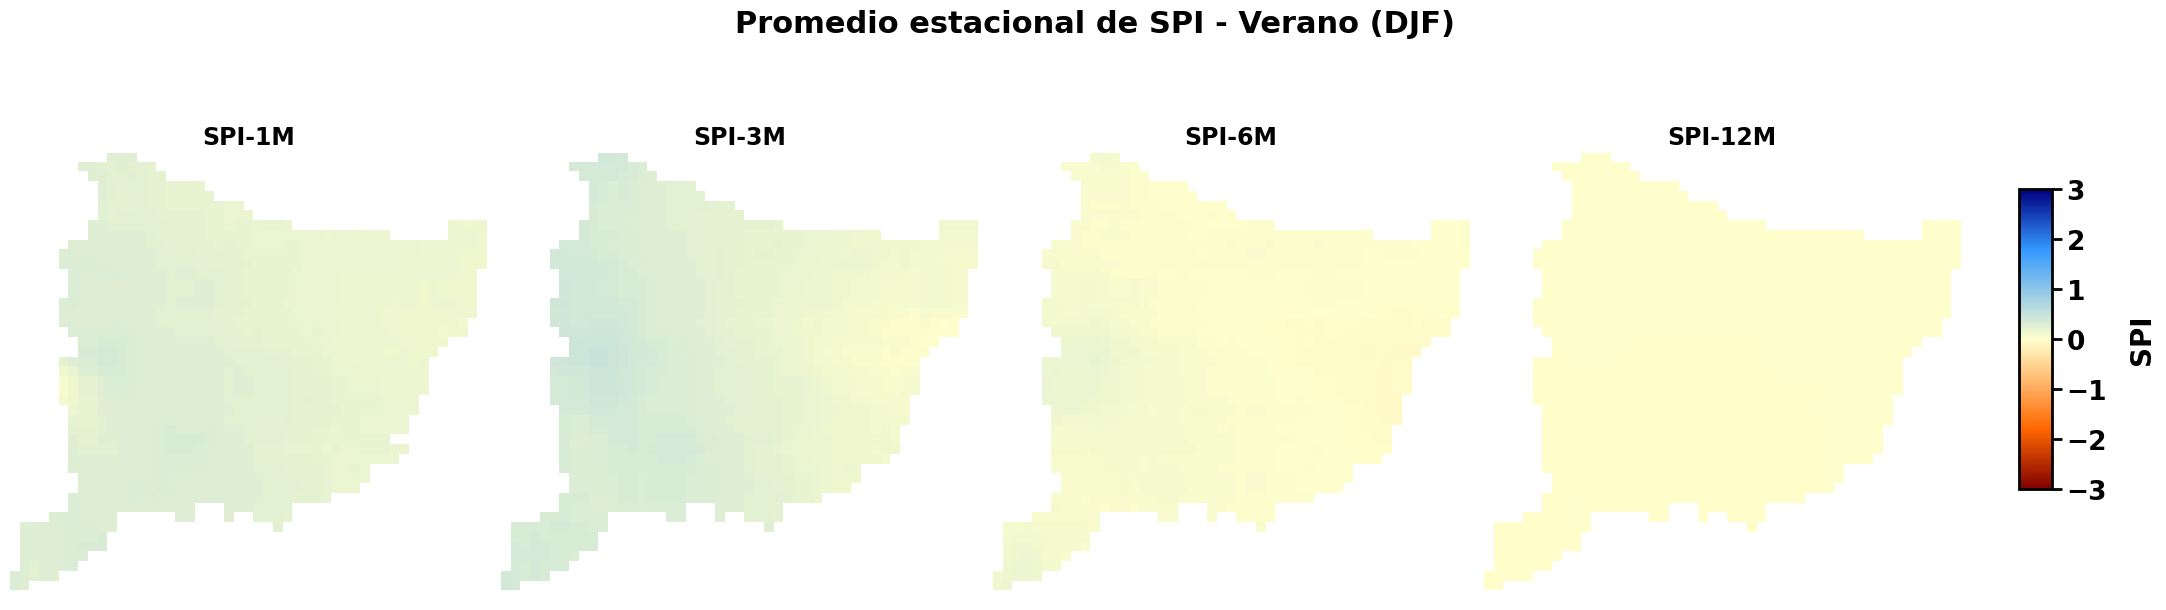

✅ Figura guardada: /content/drive/MyDrive/figuras_spi_estacionales/SPI_promedio_Otoño_MAM.png


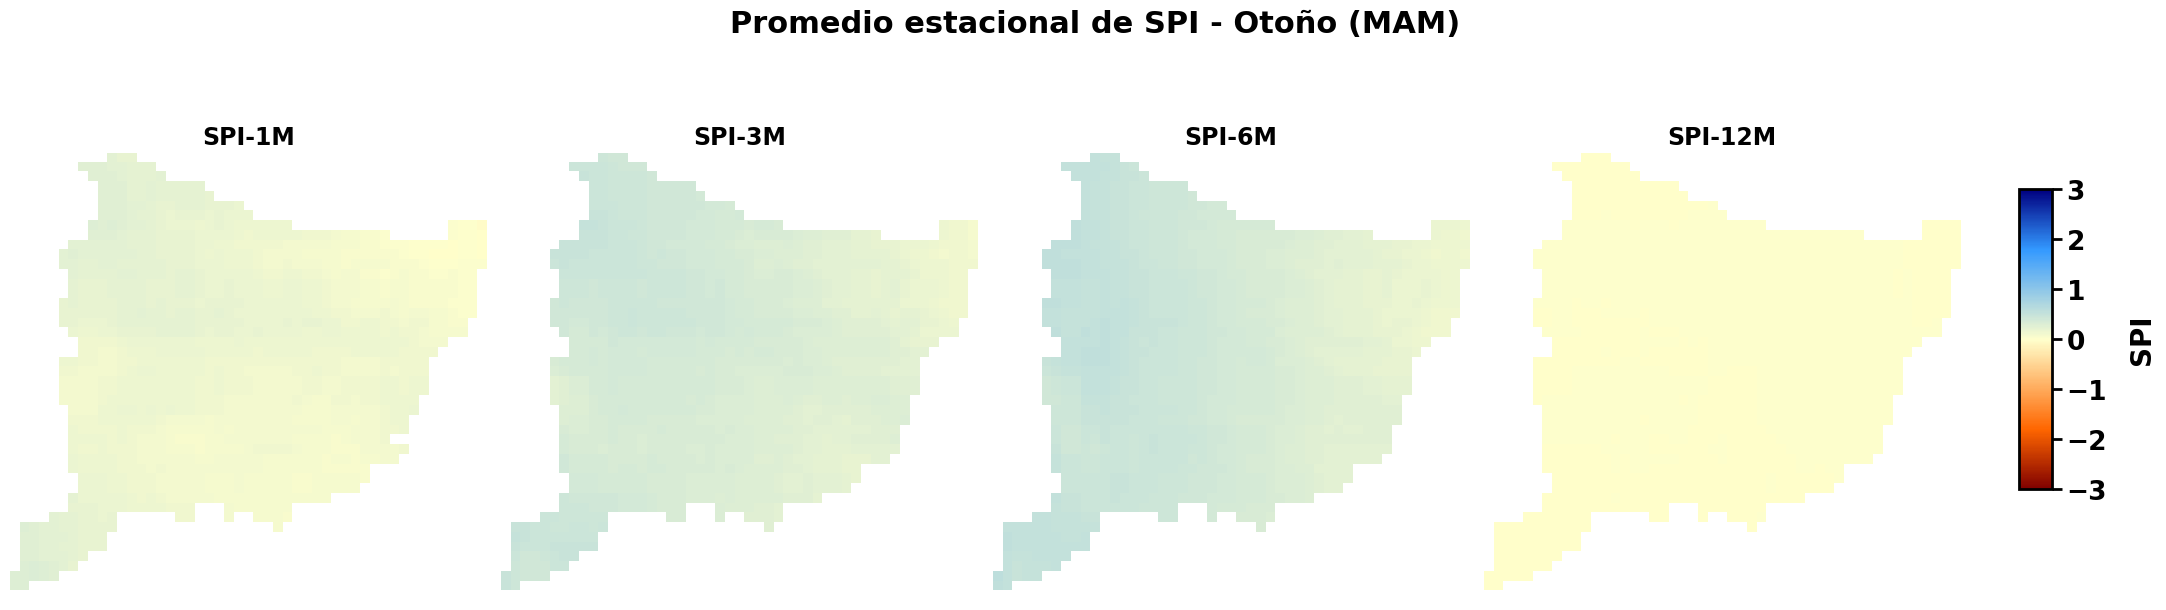

✅ Figura guardada: /content/drive/MyDrive/figuras_spi_estacionales/SPI_promedio_Invierno_JJA.png


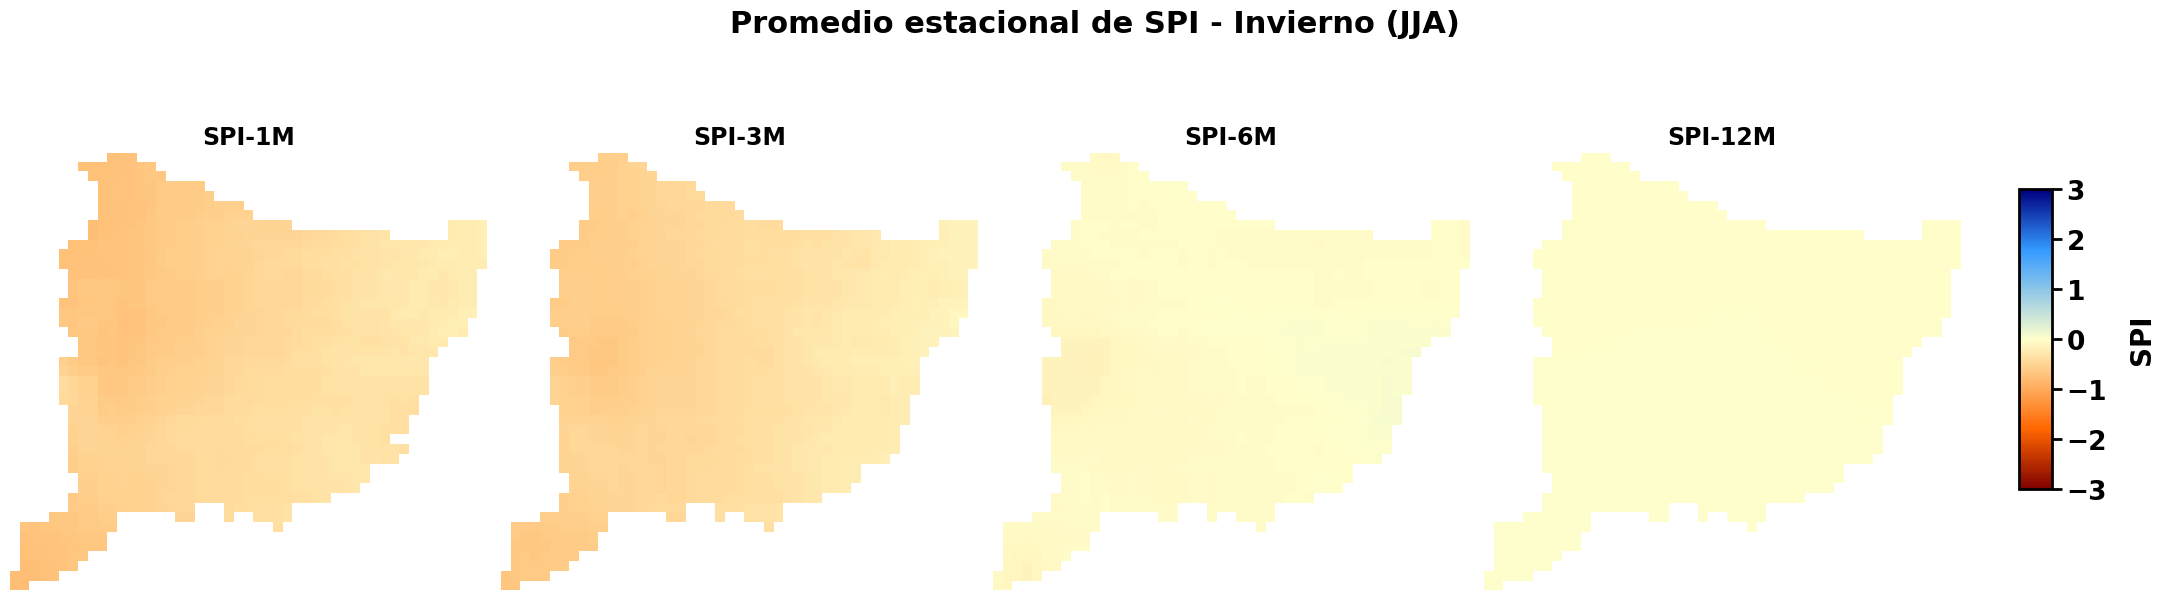

✅ Figura guardada: /content/drive/MyDrive/figuras_spi_estacionales/SPI_promedio_Primavera_SON.png


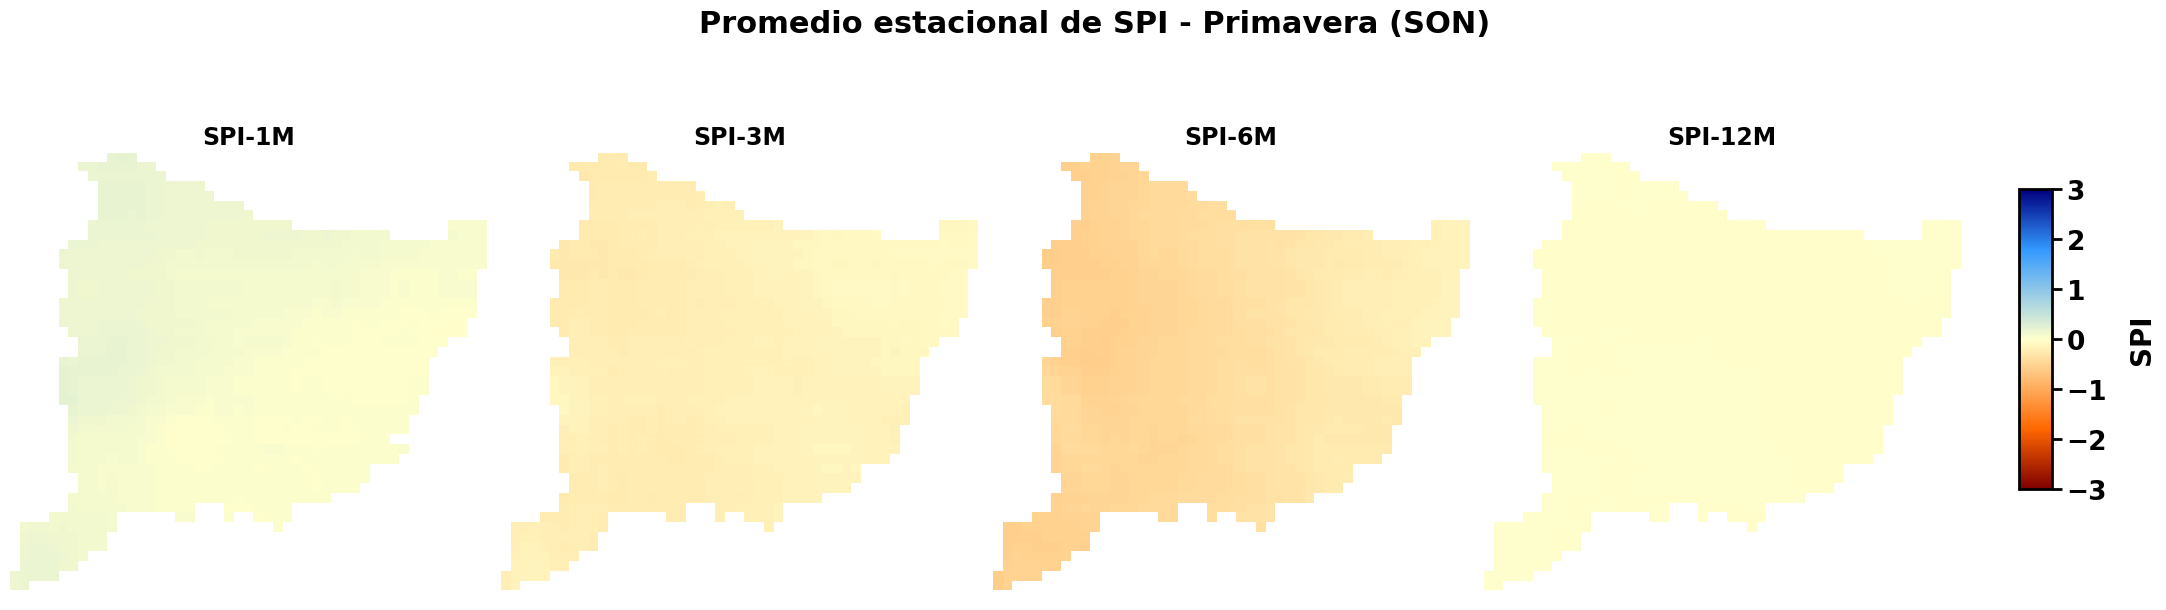

In [10]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr
from matplotlib.colors import LinearSegmentedColormap

# ==== PARÁMETROS COMUNES ====
spi_vmin = -3
spi_vmax = 3

# Paleta de colores personalizada SPI
colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),  # sequía extrema (rojo oscuro)
        (0.2, "#ff6600"),  # sequía moderada (naranja)
        (0.5, "#ffffcc"),  # normal (beige claro)
        (0.8, "#3399ff"),  # húmedo moderado (celeste)
        (1.0, "#000080")   # húmedo extremo (azul oscuro)
    ]
)

# Ruta a archivos raster
ruta_rasters = '/content/drive/MyDrive/resultados_spi'

# Carga de rasters
rasters = {
    'SPI-1M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_1m.tif'), masked=True).squeeze(),
    'SPI-3M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_3m.tif'), masked=True).squeeze(),
    'SPI-6M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_6m.tif'), masked=True).squeeze(),
    'SPI-12M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_12m.tif'), masked=True).squeeze()
}

# Fechas de las bandas (360 meses desde 1994-01)
fechas = pd.date_range(start="1994-01-01", periods=rasters['SPI-1M'].shape[0], freq="MS")

# ==== DEFINICIÓN DE ESTACIONES ====
estaciones = {
    "Verano (DJF)": [12, 1, 2],
    "Otoño (MAM)": [3, 4, 5],
    "Invierno (JJA)": [6, 7, 8],
    "Primavera (SON)": [9, 10, 11]
}

# ==== PROMEDIOS ESTACIONALES ====
promedios_estacionales = {est: {} for est in estaciones.keys()}
for nombre_spi, data in rasters.items():
    for estacion, meses in estaciones.items():
        idx = [i for i, f in enumerate(fechas) if f.month in meses]
        data_est = data.isel(band=idx)
        promedios_estacionales[estacion][nombre_spi] = data_est.mean(dim="band")

# ==== CARPETA DE SALIDA ====
carpeta_salida = "/content/drive/MyDrive/figuras_spi_estacionales"
os.makedirs(carpeta_salida, exist_ok=True)

# ==== GRAFICAR Y GUARDAR CADA ESTACIÓN POR SEPARADO ====
for estacion, valores_spi in promedios_estacionales.items():
    fig, axs = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(f"Promedio estacional de SPI - {estacion}",
                 fontsize=22, fontweight="bold", y=1.05)

    im = None
    for col, (spi, data) in enumerate(valores_spi.items()):
        ax = axs[col]
        im = ax.imshow(data, cmap=colores_spi, vmin=spi_vmin, vmax=spi_vmax)
        ax.set_title(f"{spi}", fontsize=17, fontweight="bold")
        ax.axis("off")

    # === Barra de colores individual para cada figura ===
    cax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cbar = fig.colorbar(im, cax=cax, orientation="vertical")
    cbar.set_label("SPI", fontsize=20, fontweight="bold", labelpad=15)
    cbar.ax.tick_params(labelsize=19, width=2, length=7, colors='black')
    for tick in cbar.ax.get_yticklabels():
        tick.set_fontweight('bold')
    cbar.outline.set_linewidth(2)
    cbar.set_ticks([-3, -2, -1, 0, 1, 2, 3])

    plt.tight_layout(rect=[0, 0, 0.9, 0.95])

    # === Guardar ===
    nombre_archivo = f"SPI_promedio_{estacion.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    ruta_salida = os.path.join(carpeta_salida, nombre_archivo)
    plt.savefig(ruta_salida, dpi=400, bbox_inches="tight")
    print(f"✅ Figura guardada: {ruta_salida}")
    plt.show()

Ingrese fecha de inicio (YYYY-MM): 2007-07
Ingrese fecha de fin (YYYY-MM): 2007-07
✅ Figura guardada en: figuras_spi/SPI_2007-07_2007-07.png


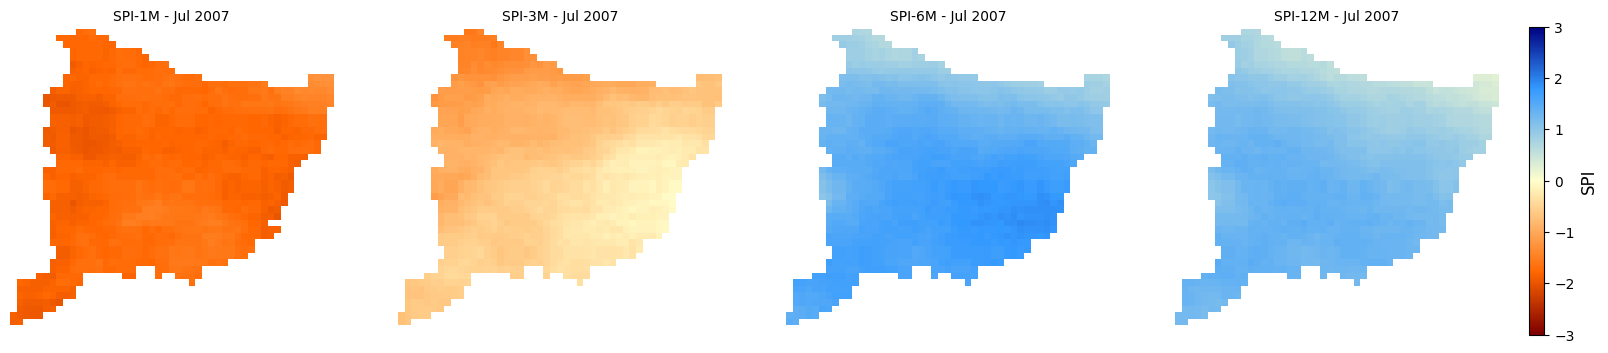

In [11]:
# Parámetros comunes de rango SPI
spi_vmin = -3
spi_vmax = 3

# Colormap común
colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),  # sequía extrema (rojo oscuro)
        (0.2, "#ff6600"),  # sequía moderada (naranja)
        (0.5, "#ffffcc"),  # normal (beige claro)
        (0.8, "#3399ff"),  # húmedo moderado (celeste)
        (1.0, "#000080")   # húmedo extremo (azul oscuro)
    ]
)

# Ruta a archivos raster
ruta_rasters = '/content/drive/MyDrive/resultados_spi'

# Carga de rasters
rasters = {
    'SPI-1M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_1m.tif'), masked=True).squeeze(),
    'SPI-3M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_3m.tif'), masked=True).squeeze(),
    'SPI-6M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_6m.tif'), masked=True).squeeze(),
    'SPI-12M': rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_12m.tif'), masked=True).squeeze()
}

# Fechas para las bandas
fechas = pd.date_range(start='1994-01-01', periods=360, freq='MS')

def graficar_spi_completo(fecha_inicio, fecha_fin, guardar=False, carpeta_salida="figuras_spi"):
    fechas_rango = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='MS')
    indices = [fechas.get_loc(f) for f in fechas_rango]

    fig, axs = plt.subplots(len(fechas_rango), 4, figsize=(20, 4 * len(fechas_rango)))
    spi_names = ['SPI-1M', 'SPI-3M', 'SPI-6M', 'SPI-12M']

    if len(fechas_rango) == 1:
        axs = axs.reshape(1, 4)

    for i, (fecha, idx) in enumerate(zip(fechas_rango, indices)):
        for j, spi in enumerate(spi_names):
            data = rasters[spi].isel(band=idx)
            ax = axs[i][j]
            im = ax.imshow(data, cmap=colores_spi, vmin=spi_vmin, vmax=spi_vmax)
            ax.set_title(f'{spi} - {fecha.strftime("%b %Y")}', fontsize=10)
            ax.axis('off')

    plt.subplots_adjust(right=0.9)
    cbar = fig.colorbar(im, ax=axs.ravel().tolist(), orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label('SPI', fontsize=12)

    if guardar:
        os.makedirs(carpeta_salida, exist_ok=True)
        nombre_archivo = f"SPI_{fecha_inicio}_{fecha_fin}.png"
        ruta_salida = os.path.join(carpeta_salida, nombre_archivo)
        plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
        print(f"✅ Figura guardada en: {ruta_salida}")

    plt.show()


# --- PEDIR FECHAS AL USUARIO Y GRAFICAR ---
fecha_inicio_input = input("Ingrese fecha de inicio (YYYY-MM): ")
fecha_fin_input = input("Ingrese fecha de fin (YYYY-MM): ")

graficar_spi_completo(fecha_inicio_input, fecha_fin_input, guardar=True)

In [12]:
def raster_to_df_from_band(raster, nombre, fecha_inicio="1981-01"):
    """
    Convierte un raster con dimensión 'band' en un DataFrame de promedio mensual.
    raster: DataArray (band, y, x)
    nombre: nombre de la columna
    fecha_inicio: fecha inicial del band 1 (ej: '1981-01')
    """
    # Promedio espacial
    serie = raster.mean(dim=["x", "y"], skipna=True).to_series()

    # Crear índice temporal a partir de 'band'
    fechas = pd.date_range(start=fecha_inicio, periods=serie.shape[0], freq="M")
    serie.index = fechas

    return serie.to_frame(name=nombre)

# Aplicar a tus rasters
df_spi1 = raster_to_df_from_band(rasters['SPI-1M'], "SPI-1", fecha_inicio="1994-01")
df_spi3 = raster_to_df_from_band(rasters['SPI-3M'], "SPI-3", fecha_inicio="1994-01")
df_spi6 = raster_to_df_from_band(rasters['SPI-6M'], "SPI-6", fecha_inicio="1994-01")
df_spi12 = raster_to_df_from_band(rasters['SPI-12M'], "SPI-12", fecha_inicio="1994-01")

# DataFrame unificado
df_all = pd.concat([df_spi1, df_spi3, df_spi6, df_spi12], axis=1)

/tmp/ipython-input-4029091672.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start=fecha_inicio, periods=serie.shape[0], freq="M")
/tmp/ipython-input-4029091672.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start=fecha_inicio, periods=serie.shape[0], freq="M")
/tmp/ipython-input-4029091672.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start=fecha_inicio, periods=serie.shape[0], freq="M")
/tmp/ipython-input-4029091672.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start=fecha_inicio, periods=serie.shape[0], freq="M")


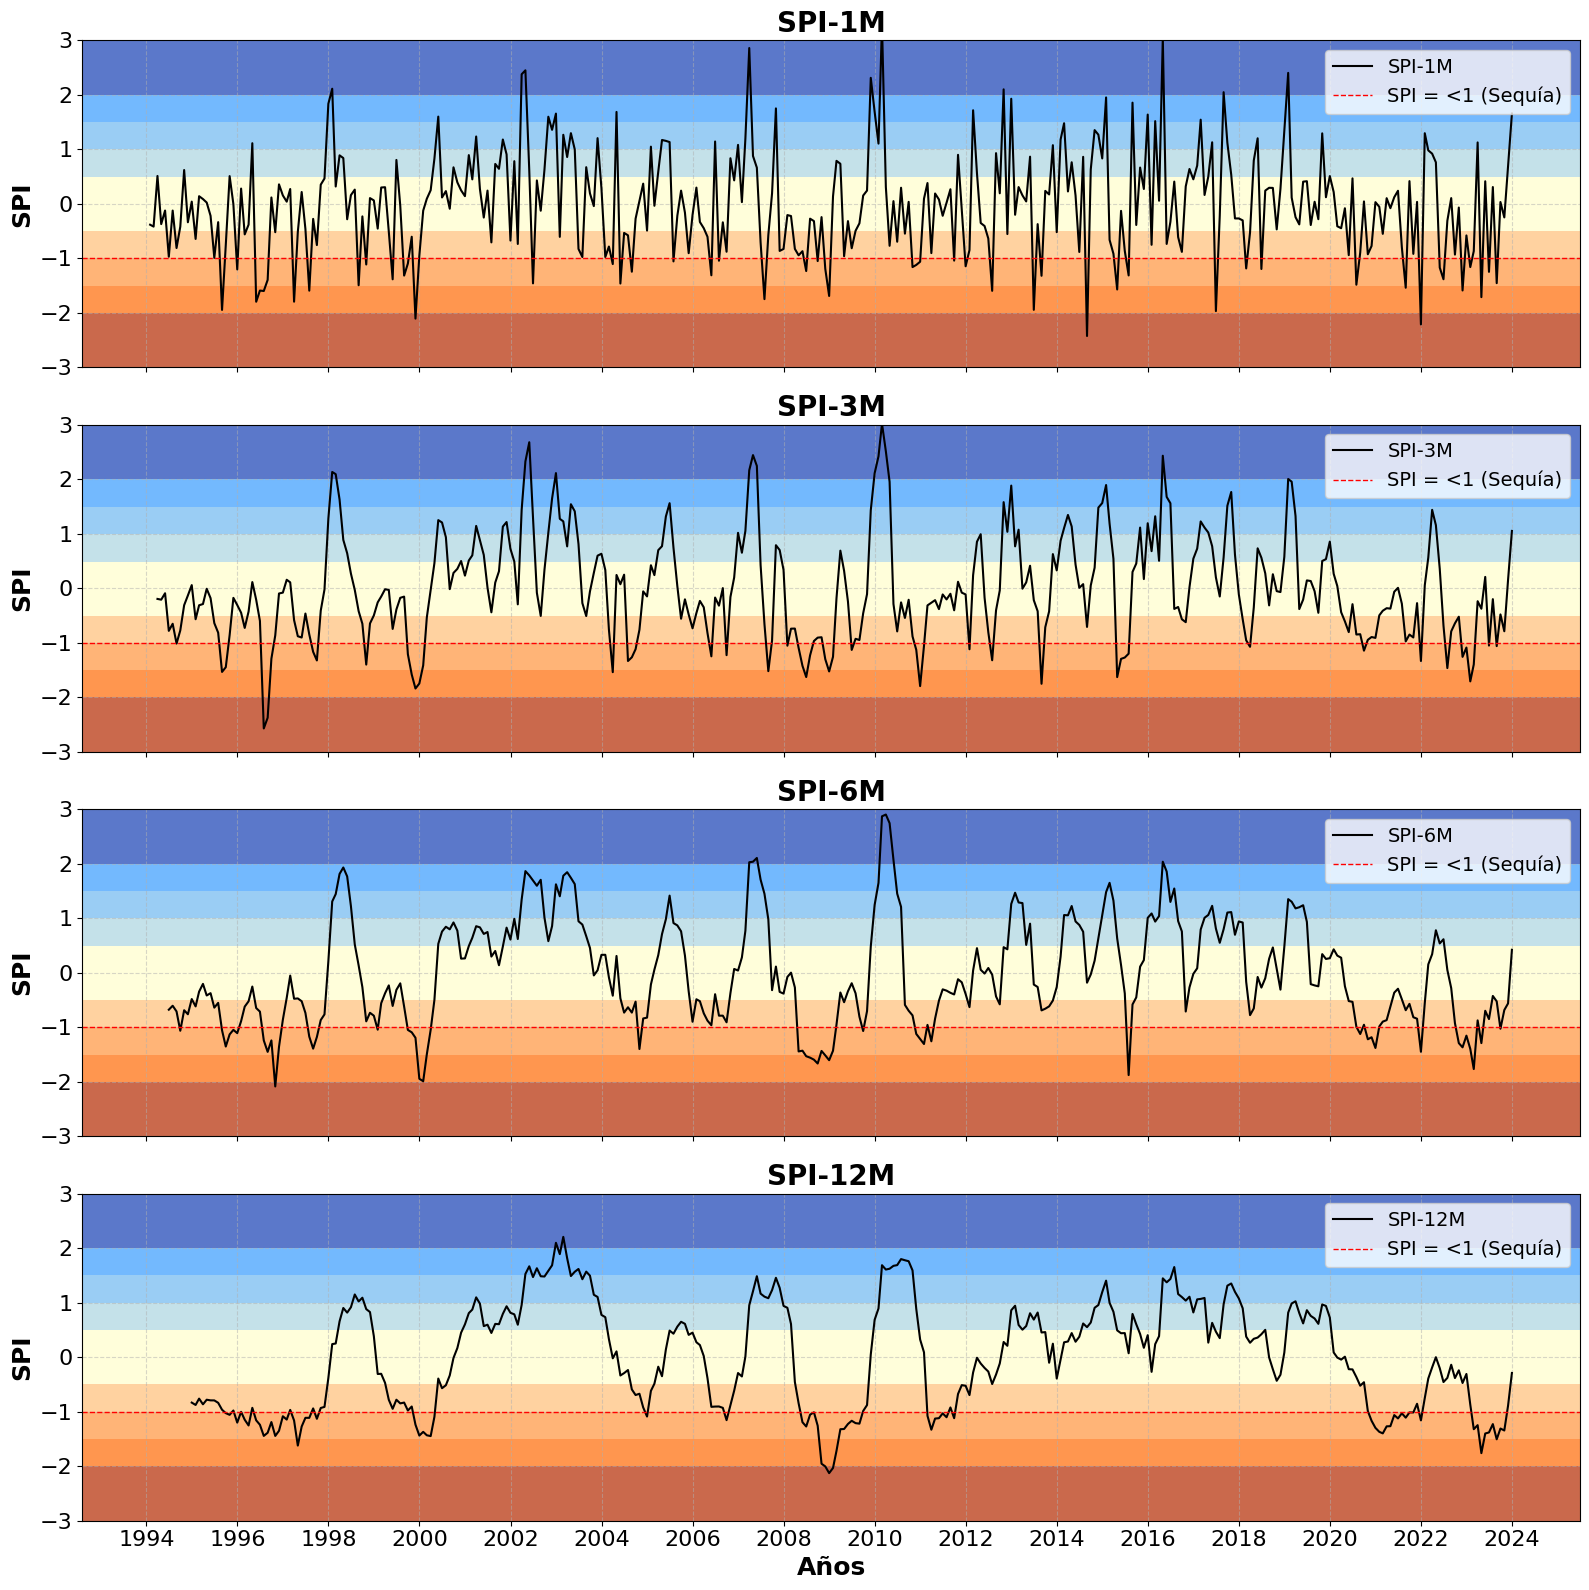

In [13]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Usar df_all con tus datos reales ---
series_dict = {
    'SPI-1M': (df_all['SPI-1'], 'black'),
    'SPI-3M': (df_all['SPI-3'], 'black'),
    'SPI-6M': (df_all['SPI-6'], 'black'),
    'SPI-12M': (df_all['SPI-12'], 'black'),
}

# --- Parámetros globales ---
spi_vmin = -3
spi_vmax = 3

# Colormap personalizado para SPI
colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),   # rojo oscuro = muy seco
        (0.2, "#ff6600"),   # naranja = seco
        (0.5, "#ffffcc"),   # amarillo claro = normal
        (0.8, "#3399ff"),   # celeste = húmedo
        (1.0, "#000080"),   # azul oscuro = muy húmedo
    ]
)

# Clasificación del SPI
clasificacion = [
    (-np.inf, -2.00, 'Extremadamente Seco'),
    (-2.00, -1.50, 'Muy Seco'),
    (-1.50, -1.00, 'Moderadamente Seco'),
    (-1.00, -0.50, 'Ligeramente Seco'),
    (-0.50, 0.49, 'Normal'),
    (0.49, 1.00, 'Ligeramente Húmedo'),
    (1.00, 1.50, 'Moderadamente Húmedo'),
    (1.50, 2.00, 'Muy Húmedo'),
    (2.00, np.inf, 'Extremadamente Húmedo'),
]

# Función para obtener color según valor SPI
def obtener_color_por_valor(mapa_colores, valor):
    val_normalizado = np.clip((valor - spi_vmin) / (spi_vmax - spi_vmin), 0, 1)
    return mapa_colores(val_normalizado)

# Función de graficado
def graficar_series_spi(series_dict):
    fig, axs = plt.subplots(len(series_dict), 1, figsize=(16, 16), sharex=True)

    for ax, (nombre, (serie, color)) in zip(axs, series_dict.items()):
        # Fondo por clasificación
        for (ymin, ymax, etiqueta) in clasificacion:
            y0 = max(ymin, spi_vmin)
            y1 = min(ymax, spi_vmax)
            if y1 <= y0:
                continue
            valor_medio = (y0 + y1) / 2
            color_fondo = obtener_color_por_valor(colores_spi, valor_medio)
            ax.axhspan(y0, y1, facecolor=color_fondo, alpha=0.7)

        # Serie temporal real
        ax.plot(serie.index, serie.values, label=nombre, linewidth=1.5, color=color)
        ax.axhline(-1, color='red', linestyle='--', linewidth=1, label='SPI = <1 (Sequía)')

        # Etiquetas y título (aumentadas en 2 puntos)
        ax.set_ylabel('SPI', fontsize=18, fontweight='bold')
        ax.set_title(f'{nombre}', fontsize=20, fontweight='bold')

        # Estética
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylim(spi_vmin, spi_vmax)

        # Aumentar tamaño de ticks (a 14)
        ax.tick_params(axis='both', labelsize=16)

    # Etiqueta eje X en el último subplot
    axs[-1].set_xlabel('Años', fontsize=18, fontweight='bold')
    axs[-1].xaxis.set_major_locator(mdates.YearLocator(base=2))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig("spi.png", dpi=300)
    plt.show()

# --- Ejecutar con tus datos ---
graficar_series_spi(series_dict)

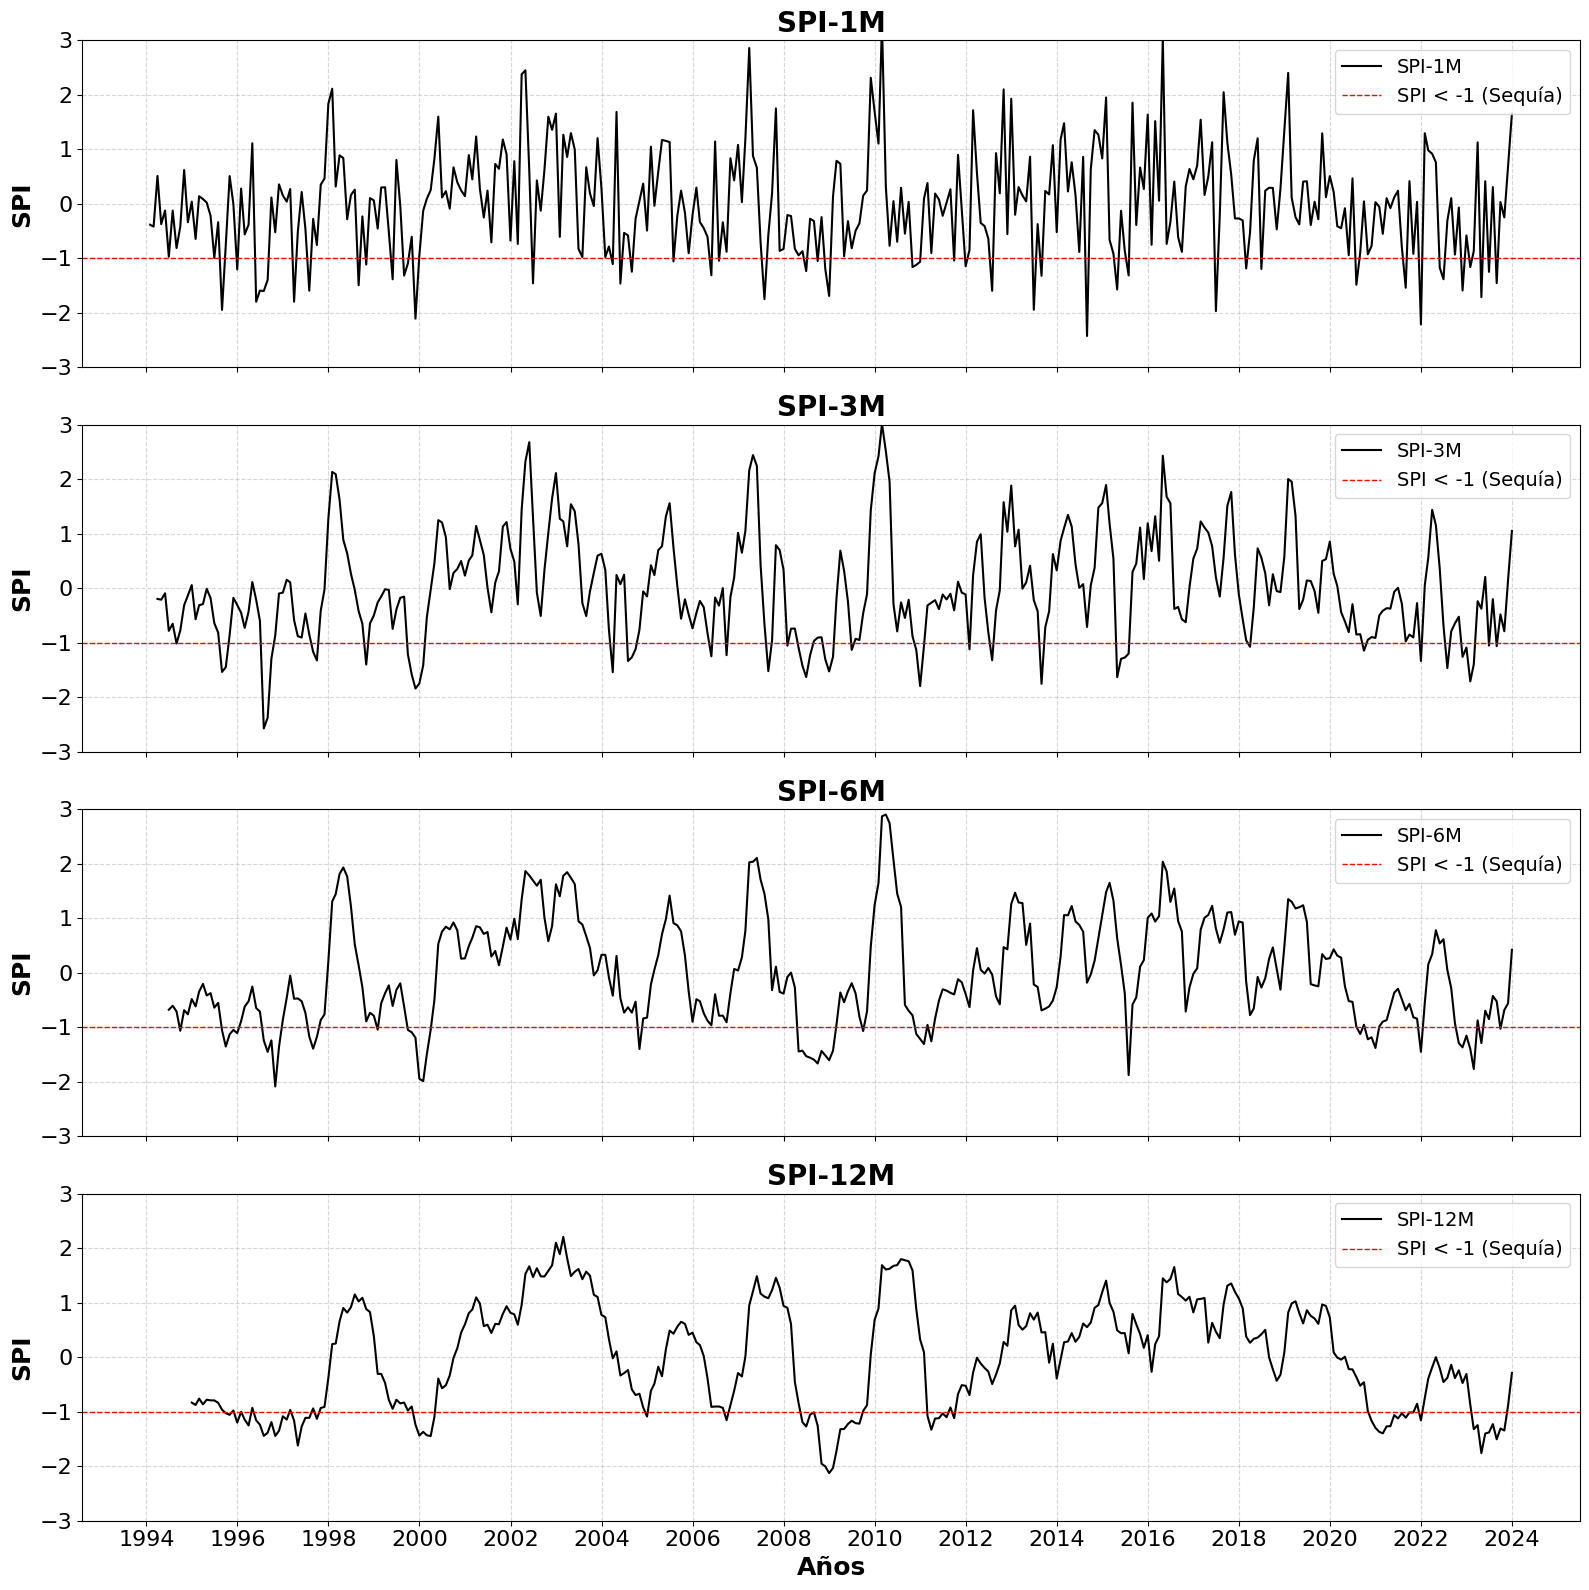

In [14]:
# --- Usar df_all con tus datos reales ---
series_dict = {
    'SPI-1M': (df_all['SPI-1'], 'black'),
    'SPI-3M': (df_all['SPI-3'], 'black'),
    'SPI-6M': (df_all['SPI-6'], 'black'),
    'SPI-12M': (df_all['SPI-12'], 'black'),
}

# --- Parámetros globales ---
spi_vmin = -3
spi_vmax = 3

# Colormap (ya no se usará para colorear fondo, pero lo dejo por compatibilidad si luego lo necesitas)
colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),   # rojo oscuro = muy seco
        (0.2, "#ff6600"),   # naranja = seco
        (0.5, "#ffffcc"),   # amarillo claro = normal
        (0.8, "#3399ff"),   # celeste = húmedo
        (1.0, "#000080"),   # azul oscuro = muy húmedo
    ]
)

# Función de graficado SIN escala de colores
def graficar_series_spi(series_dict):
    fig, axs = plt.subplots(len(series_dict), 1, figsize=(16, 16), sharex=True)

    for ax, (nombre, (serie, color)) in zip(axs, series_dict.items()):
        # --- Eliminamos el fondo coloreado por clasificación ---
        # Serie temporal real
        ax.plot(serie.index, serie.values, label=nombre, linewidth=1.5, color=color)
        ax.axhline(-1, color='red', linestyle='--', linewidth=1, label='SPI < -1 (Sequía)')

        # Etiquetas y título
        ax.set_ylabel('SPI', fontsize=18, fontweight='bold')
        ax.set_title(f'{nombre}', fontsize=20, fontweight='bold')

        # Estética
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylim(spi_vmin, spi_vmax)

        # Aumentar tamaño de ticks
        ax.tick_params(axis='both', labelsize=16)

    # Etiqueta eje X en el último subplot
    axs[-1].set_xlabel('Años', fontsize=18, fontweight='bold')
    axs[-1].xaxis.set_major_locator(mdates.YearLocator(base=2))
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.savefig("spi_sin_colores.png", dpi=300)
    plt.show()

# --- Ejecutar con tus datos ---
graficar_series_spi(series_dict)

In [15]:
import pandas as pd
import requests

# Descargar el archivo oficial del ONI desde NOAA
url = "https://psl.noaa.gov/data/correlation/oni.data"
response = requests.get(url)
data = response.text

# Separar líneas y preparar variables
lines = data.strip().split('\n')
records = []

# Estaciones móviles oficiales del ONI
seasons = ['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ',
           'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']

# Procesar las líneas de datos (evitando encabezado)
for line in lines[1:]:
    parts = line.strip().split()

    # Asegurarse de que hay al menos 13 columnas (año + 12 trimestres)
    if len(parts) == 13:
        year = int(parts[0])
        values = parts[1:]

        for i in range(12):
            try:
                oni = float(values[i])
            except:
                oni = None

            records.append({
                'year': year,
                'season': seasons[i],
                'ONI': oni
            })

# Crear DataFrame
oni_df = pd.DataFrame(records)

# Filtrar solo años entre 1994 y 2023
oni_df = oni_df[(oni_df['year'] >= 1994) & (oni_df['year'] <= 2023)]

# Mostrar los primeros valores para confirmar
print(oni_df.head(30))

     year season   ONI
528  1994    DJF  0.06
529  1994    JFM  0.07
530  1994    FMA  0.17
531  1994    MAM  0.31
532  1994    AMJ  0.42
533  1994    MJJ  0.41
534  1994    JJA  0.44
535  1994    JAS  0.43
536  1994    ASO  0.55
537  1994    SON  0.74
538  1994    OND  1.01
539  1994    NDJ  1.09
540  1995    DJF  0.96
541  1995    JFM  0.72
542  1995    FMA  0.53
543  1995    MAM  0.30
544  1995    AMJ  0.14
545  1995    MJJ -0.03
546  1995    JJA -0.24
547  1995    JAS -0.54
548  1995    ASO -0.81
549  1995    SON -0.97
550  1995    OND -1.00
551  1995    NDJ -0.98
552  1996    DJF -0.90
553  1996    JFM -0.75
554  1996    FMA -0.59
555  1996    MAM -0.39
556  1996    AMJ -0.31
557  1996    MJJ -0.30


In [16]:
# Mapeo de trimestres móviles a mes del medio
month_map = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

# Ajuste de año para trimestres que cierran en enero (NDJ)
def get_correct_year(row):
    if row['season'] == 'NDJ':
        return row['year'] - 1
    else:
        return row['year']

# Crear columnas de mes y fecha real
oni_df['month'] = oni_df['season'].map(month_map)
oni_df['real_year'] = oni_df.apply(get_correct_year, axis=1)
oni_df['date'] = pd.to_datetime(dict(year=oni_df['real_year'], month=oni_df['month'], day=1))

# Ordenar por fecha
oni_df = oni_df.sort_values(by='date')

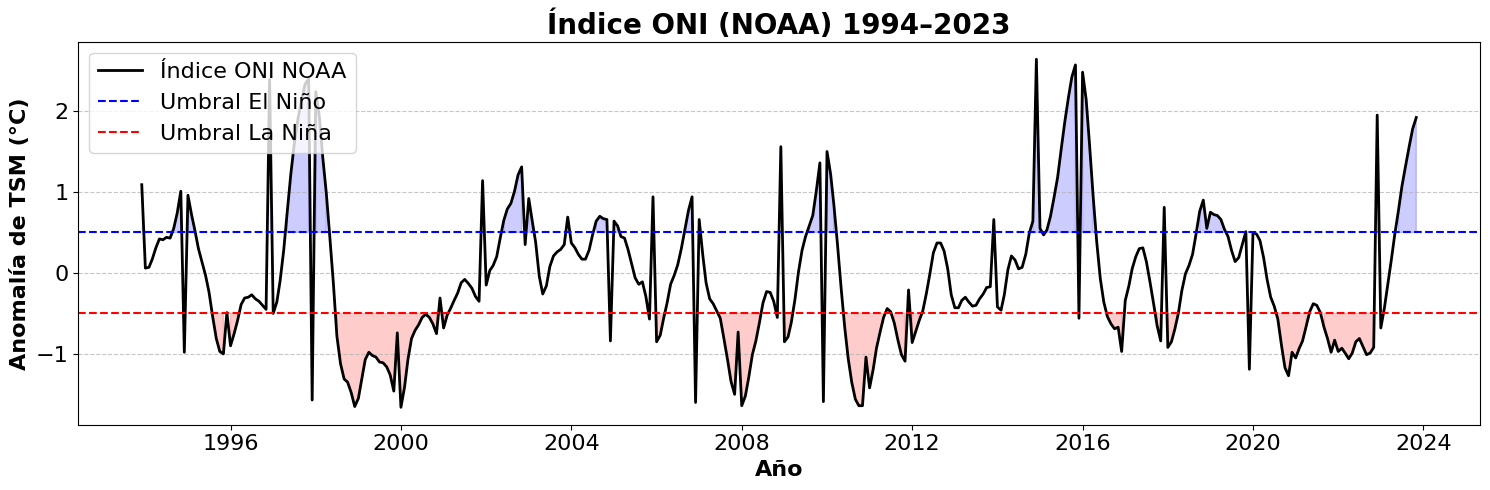

In [17]:
plt.figure(figsize=(15, 5))

# Línea ONI
plt.plot(oni_df['date'], oni_df['ONI'], label='Índice ONI NOAA', color='black', linewidth=2)

# Umbrales El Niño y La Niña
plt.axhline(0.5, color='blue', linestyle='--', linewidth=1.5, label='Umbral El Niño')
plt.axhline(-0.5, color='red', linestyle='--', linewidth=1.5, label='Umbral La Niña')

# Relleno de El Niño
plt.fill_between(
    oni_df['date'],
    0.5,
    oni_df['ONI'],
    where=oni_df['ONI'] >= 0.5,
    color='blue',
    alpha=0.2
)

# Relleno de La Niña
plt.fill_between(
    oni_df['date'],
    -0.5,
    oni_df['ONI'],
    where=oni_df['ONI'] <= -0.5,
    color='red',
    alpha=0.2
)

# Personalización del gráfico
plt.title('Índice ONI (NOAA) 1994–2023', fontsize=20, fontweight='bold')  # título más grande
plt.xlabel('Año', fontsize=16, fontweight='bold')  # eje X más grande
plt.ylabel('Anomalía de TSM (°C)', fontsize=16, fontweight='bold')  # eje Y más grande

# Cuadrícula punteada
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Leyenda más grande
plt.legend(fontsize=16, loc='upper left')

# Aumentar tamaño de los ticks
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Ajuste de layout
plt.tight_layout()
plt.savefig("oni].png", dpi=300)
plt.show()

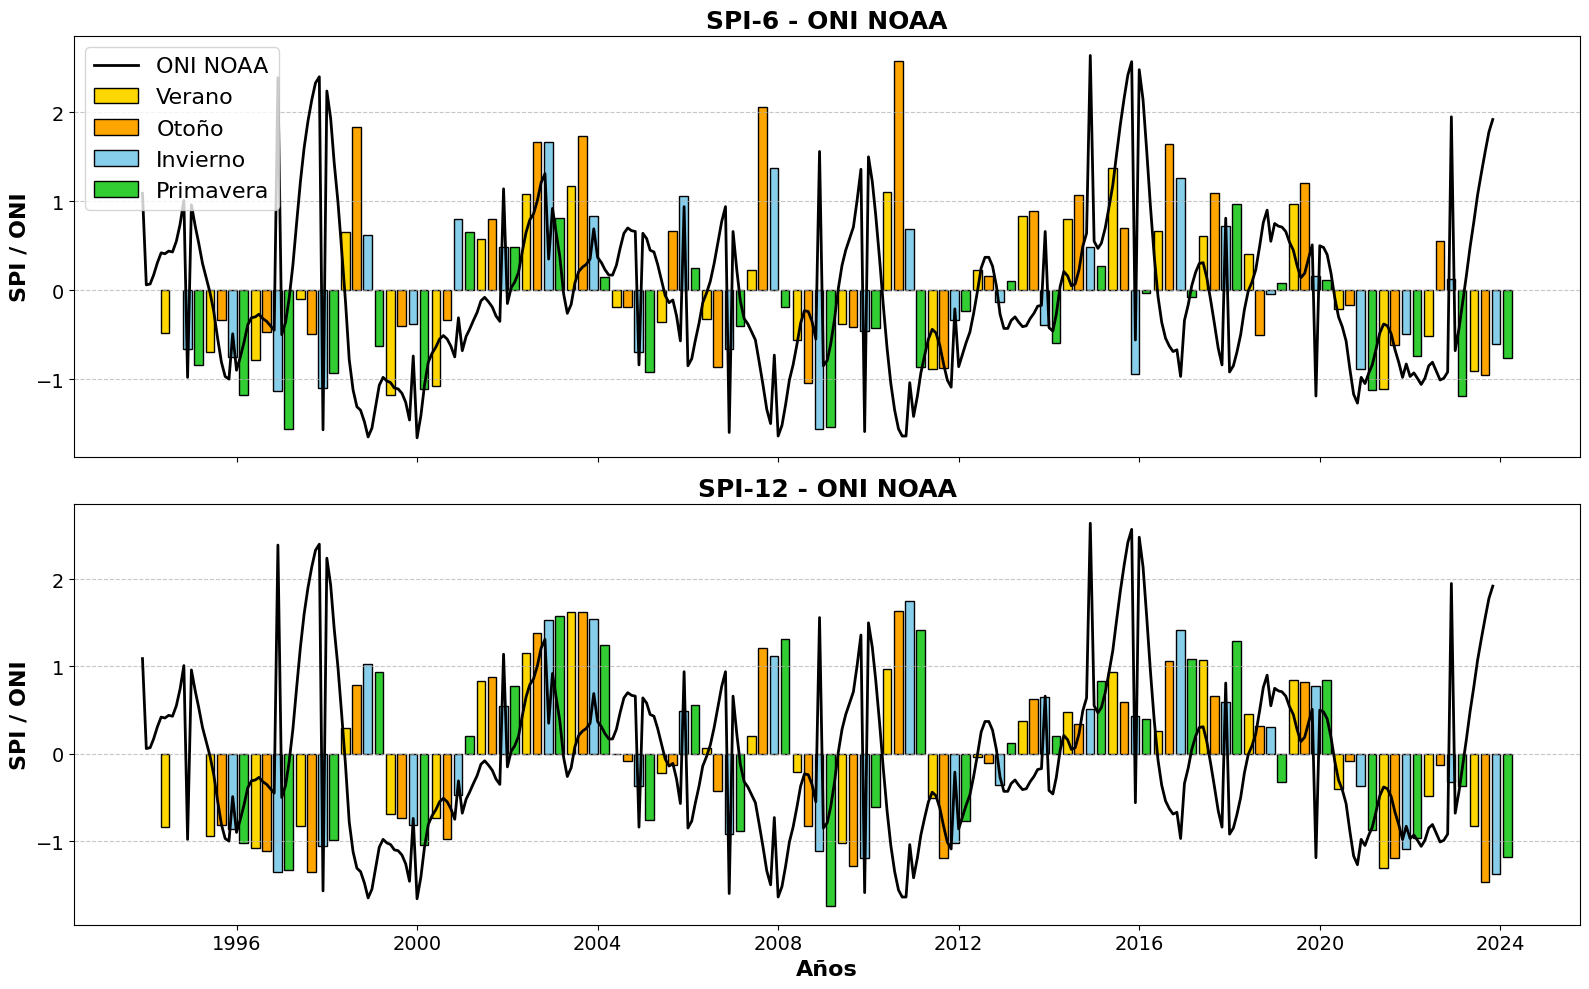

In [18]:
# -------------------------------
# ONI NOAA
# -------------------------------
url = "https://psl.noaa.gov/data/correlation/oni.data"
response = requests.get(url)
data = response.text

lines = data.strip().split('\n')
records = []
seasons = ['DJF','JFM','FMA','MAM','AMJ','MJJ',
           'JJA','JAS','ASO','SON','OND','NDJ']

for line in lines[1:]:
    parts = line.strip().split()
    if len(parts) == 13:
        year = int(parts[0])
        values = parts[1:]
        for i in range(12):
            try:
                oni = float(values[i])
            except:
                oni = None
            records.append({'year': year, 'season': seasons[i], 'ONI': oni})

oni_df = pd.DataFrame(records)
oni_df = oni_df[(oni_df['year'] >= 1994) & (oni_df['year'] <= 2023)]

month_map = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4,
    'AMJ': 5, 'MJJ': 6, 'JJA': 7, 'JAS': 8,
    'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

def get_correct_year(row):
    return row['year'] - 1 if row['season'] == 'NDJ' else row['year']

oni_df['month'] = oni_df['season'].map(month_map)
oni_df['real_year'] = oni_df.apply(get_correct_year, axis=1)
oni_df['date'] = pd.to_datetime(dict(year=oni_df['real_year'],
                                     month=oni_df['month'], day=1))
oni_df = oni_df.sort_values(by='date')

# -------------------------------
# Función para preparar pivots
# -------------------------------
def preparar_pivot(df):
    if isinstance(df, pd.Series):
        df = df.to_frame(name="SPI")
    else:
        df = df.iloc[:, [0]].copy()
        df.columns = ["SPI"]
    df.index = pd.to_datetime(df.index)

    seasons = {
        12: "Verano", 1: "Verano", 2: "Verano",
        3: "Otoño", 4: "Otoño", 5: "Otoño",
        6: "Invierno", 7: "Invierno", 8: "Invierno",
        9: "Primavera", 10: "Primavera", 11: "Primavera"
    }
    df["Año"] = df.index.year
    df["Mes"] = df.index.month
    df["Estación"] = df["Mes"].map(seasons)

    pivot = df.groupby(["Año","Estación"])["SPI"].mean().unstack()
    pivot = pivot[["Verano","Otoño","Invierno","Primavera"]]
    return pivot

# -------------------------------
# Preparar SPI-6 y SPI-12
# -------------------------------
pivot6 = preparar_pivot(df_spi6)
pivot12 = preparar_pivot(df_spi12)

# -------------------------------
# Gráficos
# -------------------------------
colores = ['gold', 'orange', 'skyblue', 'limegreen']

fig, axs = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# --- SPI-6 ---
for i, est in enumerate(pivot6.columns):
    vals = pivot6[est].values
    fechas = pd.to_datetime([f"{yr}-06-01" for yr in pivot6.index])
    axs[0].bar(fechas + pd.to_timedelta(i*90, "D"),
               vals, width=70, color=colores[i],
               edgecolor="black", label=est)

axs[0].plot(oni_df['date'], oni_df['ONI'],
            color="black", linewidth=2, label="ONI NOAA")

axs[0].set_title("SPI-6 - ONI NOAA",
                 fontsize=18, fontweight="bold")
axs[0].set_ylabel("SPI / ONI", fontsize=16, fontweight="bold")
axs[0].grid(axis="y", linestyle="--", alpha=0.7)
axs[0].legend(loc="upper left", fontsize=16)

# Agrandar etiquetas de ejes
axs[0].tick_params(axis="both", labelsize=14)

# --- SPI-12 ---
for i, est in enumerate(pivot12.columns):
    vals = pivot12[est].values
    fechas = pd.to_datetime([f"{yr}-06-01" for yr in pivot12.index])
    axs[1].bar(fechas + pd.to_timedelta(i*90, "D"),
               vals, width=70, color=colores[i],
               edgecolor="black", label=est)

axs[1].plot(oni_df['date'], oni_df['ONI'],
            color="black", linewidth=2, label="ONI NOAA")

axs[1].set_title("SPI-12 - ONI NOAA",
                 fontsize=18, fontweight="bold")
axs[1].set_ylabel("SPI / ONI", fontsize=16, fontweight="bold")
axs[1].set_xlabel("Años", fontsize=16, fontweight="bold")
axs[1].grid(axis="y", linestyle="--", alpha=0.7)

#  Agrandar etiquetas de ejes
axs[1].tick_params(axis="both", labelsize=14)

# Ajuste de layout
plt.tight_layout()
plt.savefig("spis.png", dpi=300)
plt.show()

In [19]:
# --- Unir todos los SPI en un solo DataFrame mensual ---
df_spi_all = pd.DataFrame(index=df_spi1.index)
df_spi_all["SPI-1"] = df_spi1.iloc[:, 0]
df_spi_all["SPI-3"] = df_spi3.iloc[:, 0]
df_spi_all["SPI-6"] = df_spi6.iloc[:, 0]
df_spi_all["SPI-12"] = df_spi12.iloc[:, 0]

# Elegimos SPI-1 como referencia para definir eventos
serie_spi = df_spi_all["SPI-1"]

eventos = []
en_evento = False
evento_id = 0
evento_fechas = []
evento_valores = []

for fecha, valor in serie_spi.items():
    if not en_evento:
        if valor <= -1:  # empieza sequía
            en_evento = True
            evento_id += 1
            evento_fechas = [fecha]
            evento_valores = [valor]
    else:
        evento_fechas.append(fecha)
        evento_valores.append(valor)
        if valor > 0:  # termina sequía
            en_evento = False
            eventos.append({
                "Evento": evento_id,
                "Inicio": evento_fechas[0],
                "Fin": evento_fechas[-1],
                "Duración (meses)": len(evento_fechas),
                "SPI mínimo": np.min(evento_valores),
                "SPI promedio": np.mean(evento_valores),
                "Severidad": np.sum(evento_valores)  # ✅ Nueva columna agregada
            })
            evento_fechas = []
            evento_valores = []

# Convertir a DataFrame
df_eventos = pd.DataFrame(eventos)

# ---------------------------
# Asociar ONI al inicio del evento
# ---------------------------
oni_df_sorted = oni_df.sort_values("date")

df_eventos = pd.merge_asof(
    df_eventos.sort_values("Inicio"),
    oni_df_sorted[['date','ONI']],
    left_on="Inicio",
    right_on="date"
).drop(columns="date")

# ---------------------------
# Definir relación Niño/Niña
# ---------------------------
def relacion_oni(val):
    if pd.isna(val):
        return "No relacionado"
    elif val >= 0.5:
        return "El Niño"
    elif val <= -0.5:
        return "La Niña"
    else:
        return "No relacionado"

df_eventos["Relación Niño/Niña"] = df_eventos["ONI"].apply(relacion_oni)

df_eventos

,Evento,Inicio,Fin,Duración (meses),SPI mínimo,SPI promedio,Severidad,ONI,Relación Niño/Niña
0,1,1995-08-31,1995-10-31,3,-1.945134,-0.730375,-2.191126,-0.54,La Niña
1,2,1995-12-31,1996-01-31,2,-1.202270,-0.460730,-0.921461,-0.49,No relacionado
2,3,1996-05-31,1996-09-30,5,-1.795185,-1.251955,-6.259775,-0.31,No relacionado
3,4,1997-03-31,1997-05-31,3,-1.793915,-0.696831,-2.090494,-0.10,No relacionado
4,5,1997-07-31,1997-10-31,4,-1.591676,-0.567504,-2.270014,1.60,El Niño
5,6,1998-08-31,1998-11-30,4,-1.492425,-0.681863,-2.727452,-1.12,La Niña
6,7,1999-05-31,1999-06-30,2,-1.383338,-0.288676,-0.577352,-1.02,La Niña
7,8,1999-08-31,2000-02-29,7,-2.104377,-0.871014,-6.097097,-1.11,La Niña
8,9,2002-06-30,2002-07-31,2,-1.458173,-0.514086,-1.028172,0.65,El Niño
9,10,2004-03-31,2004-04-30,2,-1.103676,0.291482,0.582965,0.23,No relacionado


In [20]:
# --- Usar SPI-3M como referencia para definir eventos ---
serie_spi = df_spi_all["SPI-3"]

eventos_spi3 = []
en_evento = False
evento_id = 0
evento_fechas = []
evento_valores = []

for fecha, valor in serie_spi.items():
    if not en_evento:
        if valor <= -1:  # empieza sequía
            en_evento = True
            evento_id += 1
            evento_fechas = [fecha]
            evento_valores = [valor]
    else:
        evento_fechas.append(fecha)
        evento_valores.append(valor)
        if valor > 0:  # termina sequía
            en_evento = False
            eventos_spi3.append({
                "Evento": evento_id,
                "Inicio": evento_fechas[0],
                "Fin": evento_fechas[-1],
                "Duración (meses)": len(evento_fechas),
                "SPI mínimo": np.min(evento_valores),
                "SPI promedio": np.mean(evento_valores),
                "Severidad": np.sum(evento_valores)  # ✅ Suma de SPI durante el evento
            })
            evento_fechas = []
            evento_valores = []

# --- Convertir a DataFrame ---
df_eventos_spi3 = pd.DataFrame(eventos_spi3)

# ---------------------------
# Asociar ONI al inicio del evento
# ---------------------------
oni_df_sorted = oni_df.sort_values("date")

df_eventos_spi3 = pd.merge_asof(
    df_eventos_spi3.sort_values("Inicio"),
    oni_df_sorted[['date', 'ONI']],
    left_on="Inicio",
    right_on="date"
).drop(columns="date")

# ---------------------------
# Definir relación Niño/Niña
# ---------------------------
def relacion_oni(val):
    if pd.isna(val):
        return "No relacionado"
    elif val >= 0.5:
        return "El Niño"
    elif val <= -0.5:
        return "La Niña"
    else:
        return "No relacionado"

df_eventos_spi3["Relación Niño/Niña"] = df_eventos_spi3["ONI"].apply(relacion_oni)

# --- Mostrar resultado ---
df_eventos_spi3

,Evento,Inicio,Fin,Duración (meses),SPI mínimo,SPI promedio,Severidad,ONI,Relación Niño/Niña
0,1,1994-08-31,1994-12-31,5,-1.013782,-0.433791,-2.168953,0.43,No relacionado
1,2,1995-08-31,1996-04-30,9,-1.533648,-0.645174,-5.806570,-0.54,La Niña
2,3,1996-07-31,1997-01-31,7,-2.570690,-1.016836,-7.117850,-0.27,No relacionado
3,4,1997-08-31,1997-12-31,5,-1.323256,-0.328741,-1.643705,1.90,El Niño
4,5,1998-10-31,2000-04-30,19,-1.838132,-0.649485,-12.340220,-1.35,La Niña
5,6,2004-03-31,2004-04-30,2,-1.538384,-0.646708,-1.293415,0.23,No relacionado
6,7,2004-07-31,2005-01-31,7,-1.333320,-0.608152,-4.257065,0.47,No relacionado
7,8,2006-05-31,2006-08-31,4,-1.247498,-0.432854,-1.731415,-0.14,No relacionado
8,9,2006-09-30,2006-11-30,3,-1.226125,-0.395709,-1.187127,0.54,El Niño
9,10,2007-08-31,2007-10-31,3,-1.519399,-0.561280,-1.683839,-0.81,La Niña


In [21]:
# Guardar el DataFrame de eventos de sequía como CSV
df_eventos.to_csv("eventos_sequia_SPI1_ONI.csv", index=False)
print("Archivo 'eventos_sequia_SPI1_ONI.csv' guardado correctamente.")

Archivo 'eventos_sequia_SPI1_ONI.csv' guardado correctamente.


In [22]:
oni_df['date'] = oni_df['date'] + pd.offsets.MonthEnd(0)

In [23]:
# Asegurarse que el índice es datetime
df_all.index = pd.to_datetime(df_all.index)
oni_df['date'] = pd.to_datetime(oni_df['date'])

# Pasar el índice de df_all a columna para poder hacer merge
df_all = df_all.reset_index().rename(columns={'index': 'date'})

# Merge por columna 'date'
df_all = pd.merge(df_all, oni_df[['date', 'ONI']], on='date', how='left')

# Si querés volver a tener 'date' como índice
df_all = df_all.set_index('date')

In [24]:
df_all

,SPI-1,SPI-3,SPI-6,SPI-12,ONI
date,,,,,
1994-01-31,-0.382006,NaN,NaN,NaN,0.06
1994-02-28,-0.416686,NaN,NaN,NaN,0.07
1994-03-31,0.512179,-0.194594,NaN,NaN,0.17
1994-04-30,-0.371255,-0.208406,NaN,NaN,0.31
1994-05-31,-0.121668,-0.090688,NaN,NaN,0.42
...,...,...,...,...,...
2023-08-31,-1.453991,-1.060351,-0.524949,-1.506392,1.32
2023-09-30,0.034033,-0.478643,-1.027446,-1.308788,1.56
2023-10-31,-0.248153,-0.787502,-0.684192,-1.344782,1.78


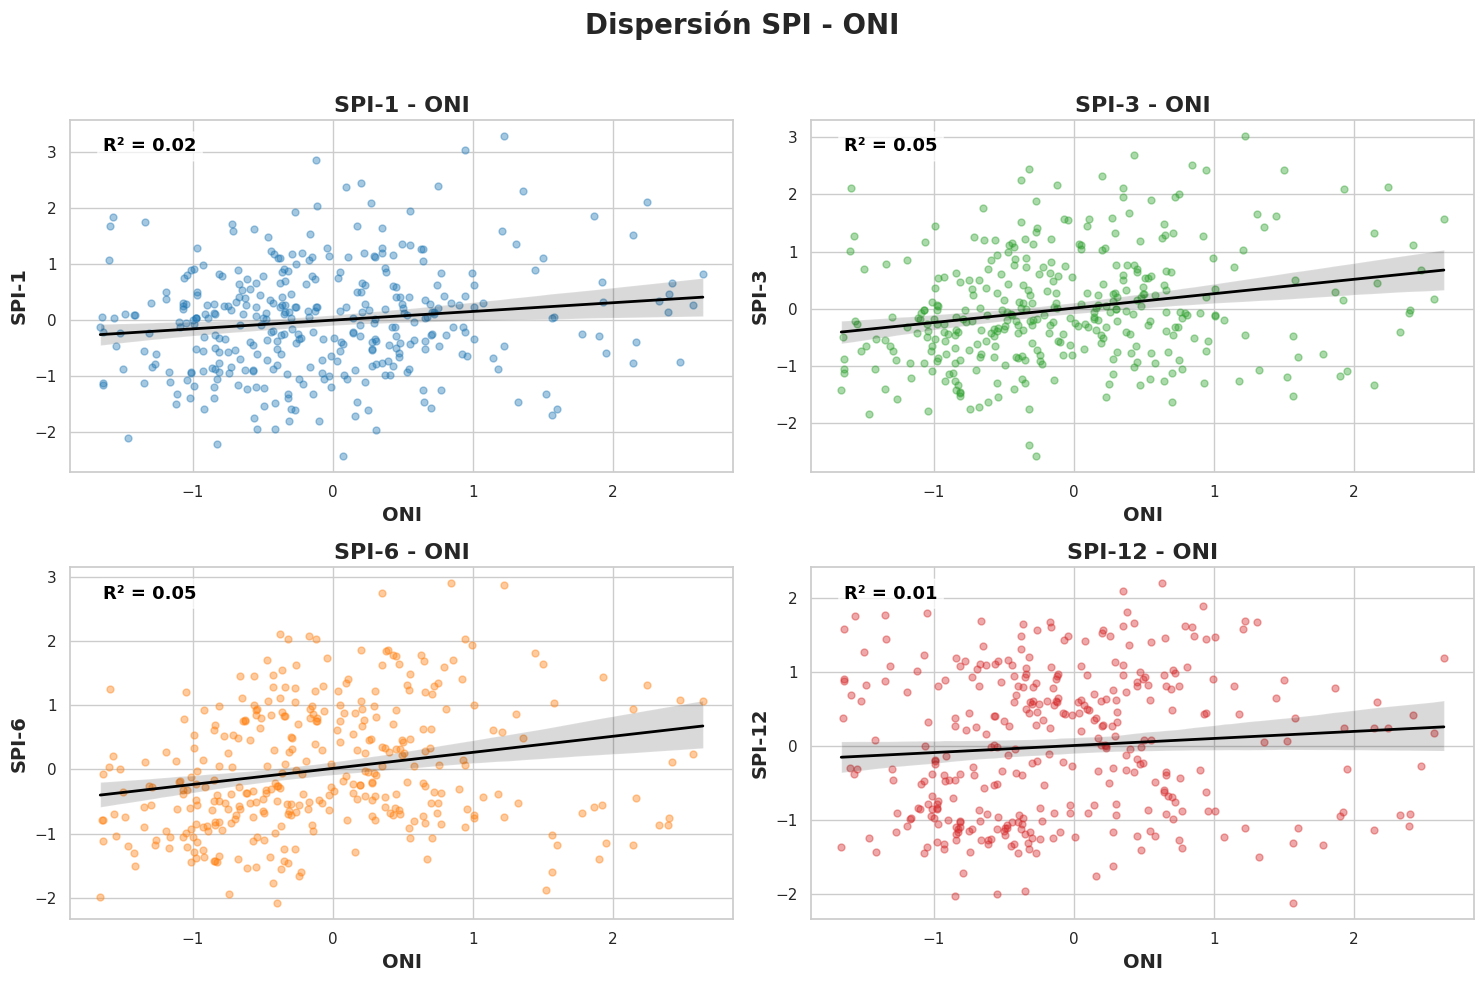

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Configuración estilo
sns.set_theme(style="whitegrid")

# Lista de SPIs y colores
spis = ["SPI-1", "SPI-3", "SPI-6", "SPI-12"]
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]  # azul, verde, naranja, rojo

# Figura con 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, spi, color in zip(axes.flatten(), spis, colors):
    # Quitar NaN
    data = df_all[[spi, "ONI"]].dropna()

    X = data["ONI"].values.reshape(-1, 1)
    y = data[spi].values

    # Ajuste lineal
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    # Calcular R²
    r2 = r2_score(y, y_pred)

    # Scatter + regresión
    sns.regplot(
        x="ONI", y=spi, data=data, ax=ax,
        scatter_kws={'alpha':0.4, 's':25, 'color':color},
        line_kws={"color":"black", "linewidth":2}
    )

    # Etiquetas y título
    ax.set_title(f"{spi} - ONI", fontsize=16, fontweight="bold")
    ax.set_xlabel("ONI", fontsize=14, fontweight="bold")
    ax.set_ylabel(spi, fontsize=14, fontweight="bold")

    # Texto con R² dentro del gráfico
    ax.text(0.05, 0.95, f"R² = {r2:.2f}", transform=ax.transAxes,
            fontsize=13, fontweight="bold", color="black",
            verticalalignment="top", bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# Ajustes generales
plt.suptitle("Dispersión SPI - ONI", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("regresiones_SPI_ONI.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Ruta a tu carpeta con los rasters
ruta_tiffs = '/content/drive/MyDrive/CHIRPS_UY/*.tif'

# Listar y ordenar archivos
archivos = sorted(glob.glob(ruta_tiffs))
print(f"{len(archivos)} archivos encontrados.")

# Extraer fechas correctamente desde nombres chirps_YYYYMM.tif
fechas = [
    pd.to_datetime(os.path.splitext(os.path.basename(f))[0].split("_")[1], format="%Y%m")
    for f in archivos
]

# Calcular promedio de cada raster
promedios = []
for f in tqdm(archivos):
    da = rxr.open_rasterio(f, masked=True).squeeze(drop=True)  # abrir raster
    prom = float(da.mean().values)  # promedio espacial
    promedios.append(prom)

# Crear DataFrame
df_precip = pd.DataFrame({
    "date": fechas,
    "PA": promedios   # PA = Precipitación Acumulada promedio mensual
})

# Asegurar orden temporal
df_precip = df_precip.sort_values("date").reset_index(drop=True)

df_precip

360 archivos encontrados.


100%|██████████| 360/360 [00:08<00:00, 41.75it/s]


,date,PA
0,1994-01-01,75.037157
1,1994-02-01,74.081700
2,1994-03-01,129.937066
3,1994-04-01,74.093050
4,1994-05-01,87.544392
...,...,...
355,2023-08-01,32.743019
356,2023-09-01,99.606924
357,2023-10-01,81.379138
358,2023-11-01,150.466140


In [27]:
df_precip['date'] = df_precip['date'] + pd.offsets.MonthEnd(0)

In [28]:
df_precip["date"] = pd.to_datetime(df_precip["date"])
df_all.index = pd.to_datetime(df_all.index)

In [29]:
df_precip.describe()

,date,PA
count,360,360.000000
mean,2009-01-14 03:08:00,107.697285
min,1994-01-31 00:00:00,12.494266
25%,2001-07-23 06:00:00,59.800213
50%,2009-01-15 12:00:00,97.184272
75%,2016-07-07 18:00:00,132.190604
max,2023-12-31 00:00:00,464.050652
std,NaN,67.701832


In [30]:
df_all

,SPI-1,SPI-3,SPI-6,SPI-12,ONI
date,,,,,
1994-01-31,-0.382006,NaN,NaN,NaN,0.06
1994-02-28,-0.416686,NaN,NaN,NaN,0.07
1994-03-31,0.512179,-0.194594,NaN,NaN,0.17
1994-04-30,-0.371255,-0.208406,NaN,NaN,0.31
1994-05-31,-0.121668,-0.090688,NaN,NaN,0.42
...,...,...,...,...,...
2023-08-31,-1.453991,-1.060351,-0.524949,-1.506392,1.32
2023-09-30,0.034033,-0.478643,-1.027446,-1.308788,1.56
2023-10-31,-0.248153,-0.787502,-0.684192,-1.344782,1.78


In [31]:
df = df_all.merge(
    df_precip.set_index("date"),
    left_index=True,
    right_index=True,
    how="outer"
)

In [32]:
df

,SPI-1,SPI-3,SPI-6,SPI-12,ONI,PA
date,,,,,,
1994-01-31,-0.382006,NaN,NaN,NaN,0.06,75.037157
1994-02-28,-0.416686,NaN,NaN,NaN,0.07,74.081700
1994-03-31,0.512179,-0.194594,NaN,NaN,0.17,129.937066
1994-04-30,-0.371255,-0.208406,NaN,NaN,0.31,74.093050
1994-05-31,-0.121668,-0.090688,NaN,NaN,0.42,87.544392
...,...,...,...,...,...,...
2023-08-31,-1.453991,-1.060351,-0.524949,-1.506392,1.32,32.743019
2023-09-30,0.034033,-0.478643,-1.027446,-1.308788,1.56,99.606924
2023-10-31,-0.248153,-0.787502,-0.684192,-1.344782,1.78,81.379138


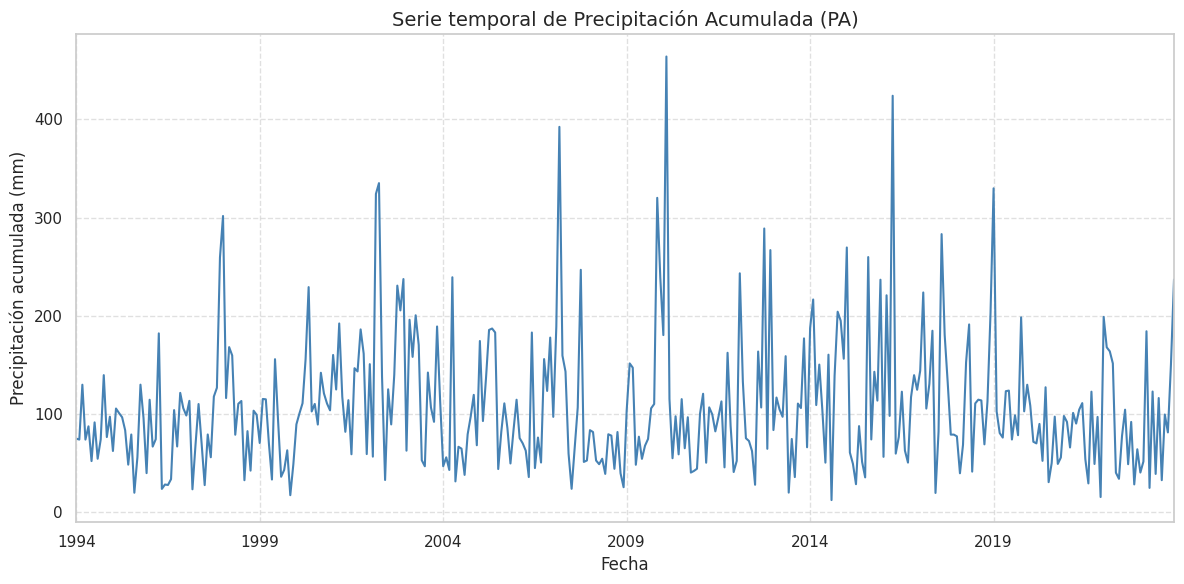

In [33]:
# Gráfico de la serie temporal de precipitación acumulada (PA)
plt.figure(figsize=(12,6))
df["PA"].plot(color="steelblue", linewidth=1.5)

plt.title("Serie temporal de Precipitación Acumulada (PA)", fontsize=14)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precipitación acumulada (mm)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
# Cuadro CORRELACIONES PARA OBJETIVO 2

In [35]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# --- FUNCIONES AUXILIARES ---

def calcular_estadisticas(x, y):
    """Devuelve las estadísticas principales entre dos series."""
    df_temp = pd.concat([x, y], axis=1).dropna()
    if len(df_temp) < 3:
        return {"Covarianza": np.nan, "Spearman": np.nan, "Pearson": np.nan, "r²": np.nan}

    cov = np.cov(df_temp.iloc[:, 0], df_temp.iloc[:, 1])[0, 1]
    spearman, _ = spearmanr(df_temp.iloc[:, 0], df_temp.iloc[:, 1])
    pearson, _ = pearsonr(df_temp.iloc[:, 0], df_temp.iloc[:, 1])
    r2 = pearson ** 2
    return {"Covarianza": cov, "Spearman": spearman, "Pearson": pearson, "r²": r2}


def correlacion_cruzada(x, y, lags=[1, 3, 6, 12]):
    """Calcula correlaciones cruzadas para ±lags."""
    resultados = {}
    for lag in lags:
        # Retraso: ONI afecta después
        if len(x) > lag:
            corr_retraso = x[lag:].corr(y[:-lag])
            corr_adelanto = x[:-lag].corr(y[lag:])
        else:
            corr_retraso, corr_adelanto = np.nan, np.nan

        resultados[f"{lag}m retraso"] = corr_retraso
        resultados[f"{lag}m adelanto"] = corr_adelanto
    return resultados


# --- CÁLCULOS PRINCIPALES ---
variables = ["SPI-1", "SPI-3", "SPI-6", "SPI-12", "PA"]
resultados = []

for var in variables:
    stats = calcular_estadisticas(df["ONI"], df[var])
    cross = correlacion_cruzada(df["ONI"], df[var])
    resultados.append({
        "Variable": var,
        **stats,
        **cross
    })

# --- GENERAR TABLA FINAL ---
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados[[
    "Variable", "Covarianza", "Spearman", "Pearson", "r²",
    "1m retraso", "1m adelanto",
    "3m retraso", "3m adelanto",
    "6m retraso", "6m adelanto",
    "12m retraso", "12m adelanto"
]]

# --- Mostrar tabla ---
print("📊 Cuadro resumen ONI vs SPI/PA")
display(df_resultados)

📊 Cuadro resumen ONI vs SPI/PA


,Variable,Covarianza,Spearman,Pearson,r²,1m retraso,1m adelanto,3m retraso,3m adelanto,6m retraso,6m adelanto,12m retraso,12m adelanto
0,SPI-1,0.119318,0.127539,0.142714,0.020367,0.142907,0.142907,0.141699,0.141699,0.152162,0.152162,0.159794,0.159794
1,SPI-3,0.194175,0.237332,0.229136,0.052503,0.229136,0.229136,0.236545,0.236545,0.250674,0.250674,0.261309,0.261309
2,SPI-6,0.194360,0.269422,0.226988,0.051524,0.226988,0.226988,0.238424,0.238424,0.253210,0.253210,0.269694,0.269694
3,SPI-12,0.074680,0.136038,0.086413,0.007467,0.086413,0.086413,0.102633,0.102633,0.124833,0.124833,0.130613,0.130613
4,PA,9.143052,0.128871,0.154764,0.023952,0.155012,0.155012,0.155531,0.155531,0.165806,0.165806,0.173098,0.173098


In [36]:
# Instalar librería si no está instalada
!pip install pymannkendall

In [37]:
import pymannkendall as mk

# Diccionario con las series SPI y sus nombres

series_spi = {
    'SPI-1M': df_all['SPI-1'],
    'SPI-3M': df_all['SPI-3'],
    'SPI-6M': df_all['SPI-6'],
    'SPI-12M': df_all['SPI-12'],
    }

alpha = 0.05 # Nivel de significancia (por defecto en MK)

# Aplicar el test de Mann-Kendall a cada serie
for nombre, serie in series_spi.items():
  print(f"\n📈 Resultados del test de Mann-Kendall para {nombre}:")
  resultado = mk.original_test(serie.dropna())
  print(f" Tendencia: {resultado.trend}")
  print(f" Estadístico Z: {resultado.z:.3f}")
  print(f" P-valor: {resultado.p:.4f}")
  print(f" Nivel de significancia: {alpha}")
  print(f" ¿Tendencia significativa?: {'Sí' if resultado.h else 'No'}")
  print(f"  Pendiente de Sen (Thiel–Sen): {resultado.slope:.6f}")


📈 Resultados del test de Mann-Kendall para SPI-1M:
 Tendencia: no trend
 Estadístico Z: 0.439
 P-valor: 0.6609
 Nivel de significancia: 0.05
 ¿Tendencia significativa?: No
  Pendiente de Sen (Thiel–Sen): 0.000199

📈 Resultados del test de Mann-Kendall para SPI-3M:
 Tendencia: no trend
 Estadístico Z: 0.730
 P-valor: 0.4653
 Nivel de significancia: 0.05
 ¿Tendencia significativa?: No
  Pendiente de Sen (Thiel–Sen): 0.000354

📈 Resultados del test de Mann-Kendall para SPI-6M:
 Tendencia: no trend
 Estadístico Z: 1.185
 P-valor: 0.2359
 Nivel de significancia: 0.05
 ¿Tendencia significativa?: No
  Pendiente de Sen (Thiel–Sen): 0.000591

📈 Resultados del test de Mann-Kendall para SPI-12M:
 Tendencia: no trend
 Estadístico Z: 0.956
 P-valor: 0.3389
 Nivel de significancia: 0.05
 ¿Tendencia significativa?: No
  Pendiente de Sen (Thiel–Sen): 0.000495


In [38]:
import pandas as pd

resultados = []

for nombre, serie in series_spi.items():
    serie = serie.dropna()
    resultado = mk.original_test(serie)
    resultados.append({
        'Serie': nombre,
        'Tendencia': resultado.trend,
        'Mann-Kendall': resultado.z,
        '': resultado.p,
        'Significativa': 'Sí' if resultado.h else 'No',
        'Pendiente_Sen': resultado.slope
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)

     Serie Tendencia  Mann-Kendall           Significativa  Pendiente_Sen
0   SPI-1M  no trend      0.438736  0.660853            No       0.000199
1   SPI-3M  no trend      0.730135  0.465308            No       0.000354
2   SPI-6M  no trend      1.185183  0.235945            No       0.000591
3  SPI-12M  no trend      0.956413  0.338864            No       0.000495


In [39]:
import numpy as np
import pandas as pd
import pymannkendall as mk
import random

# --- Parámetros ---
n_muestras = 10
años_ventana = 4

# --- Diccionario con las series SPI ---
series_spi = {
    'SPI-1M': df_all['SPI-1'],
    'SPI-3M': df_all['SPI-3'],
    'SPI-6M': df_all['SPI-6'],
    'SPI-12M': df_all['SPI-12'],
}

# --- Convertir índice a datetime si no lo está ---
df_all.index = pd.to_datetime(df_all.index)

# --- Años disponibles ---
años_disponibles = sorted(list(df_all.index.year.unique()))
max_inicio = años_disponibles[-1] - años_ventana

# ------------------------------------------------
# 1️⃣ Seleccionar periodos aleatorios una sola vez
# ------------------------------------------------
periodos_random = []
for i in range(n_muestras):
    año_inicio = random.choice([a for a in años_disponibles if a <= max_inicio])
    año_fin = año_inicio + años_ventana
    periodos_random.append((año_inicio, año_fin))

print("📅 Periodos seleccionados aleatoriamente:")
print(periodos_random)

# ------------------------------------------------
# 2️⃣ Aplicar ambos tests sobre los mismos periodos
# ------------------------------------------------

resultados_original = []
resultados_hr = []

for nombre, serie in series_spi.items():
    for (año_inicio, año_fin) in periodos_random:
        subserie = serie[(serie.index.year >= año_inicio) & (serie.index.year < año_fin)].dropna()

        if len(subserie) > 0:
            # Test original
            res_orig = mk.original_test(subserie)
            resultados_original.append({
                'Serie': nombre,
                'Periodo': f"{año_inicio}-{año_fin}",
                'Tendencia': res_orig.trend,
                'Z': res_orig.z,
                'P-valor': res_orig.p,
                'Significativa': 'Sí' if res_orig.h else 'No',
                'Pendiente_Sen': res_orig.slope,
                'N_datos': len(subserie)
            })

            # Test Hamed-Rao
            res_hr = mk.hamed_rao_modification_test(subserie)
            resultados_hr.append({
                'Serie': nombre,
                'Periodo': f"{año_inicio}-{año_fin}",
                'Tendencia': res_hr.trend,
                'Z': res_hr.z,
                'P-valor': res_hr.p,
                'Significativa': 'Sí' if res_hr.h else 'No',
                'Pendiente_Sen': res_hr.slope,
                'N_datos': len(subserie)
            })

# Convertir a DataFrames
df_original = pd.DataFrame(resultados_original)
df_hr = pd.DataFrame(resultados_hr)

print("✅ Resultados del test Mann–Kendall (original):")
display(df_original)

print("\n✅ Resultados del test Mann–Kendall (Hamed–Rao corregido):")
display(df_hr)

📅 Periodos seleccionados aleatoriamente:
[(2000, 2004), (2000, 2004), (2015, 2019), (1994, 1998), (1997, 2001), (2001, 2005), (2009, 2013), (2018, 2022), (2019, 2023), (1994, 1998)]
✅ Resultados del test Mann–Kendall (original):


,Serie,Periodo,Tendencia,Z,P-valor,Significativa,Pendiente_Sen,N_datos
0,SPI-1M,2000-2004,no trend,0.808812,4.186235e-01,No,0.006339,48
1,SPI-1M,2000-2004,no trend,0.808812,4.186235e-01,No,0.006339,48
2,SPI-1M,2015-2019,no trend,0.666603,5.050257e-01,No,0.008291,48
3,SPI-1M,1994-1998,no trend,0.435514,6.631894e-01,No,0.003609,48
4,SPI-1M,1997-2001,no trend,0.648827,5.164502e-01,No,0.004712,48
5,SPI-1M,2001-2005,decreasing,-2.053137,4.005926e-02,Sí,-0.022926,48
6,SPI-1M,2009-2013,no trend,-0.275529,7.829097e-01,No,-0.003136,48
7,SPI-1M,2018-2022,no trend,-1.946481,5.159701e-02,No,-0.012840,48
8,SPI-1M,2019-2023,no trend,-1.715392,8.627342e-02,No,-0.014081,48
9,SPI-1M,1994-1998,no trend,0.435514,6.631894e-01,No,0.003609,48



✅ Resultados del test Mann–Kendall (Hamed–Rao corregido):


,Serie,Periodo,Tendencia,Z,P-valor,Significativa,Pendiente_Sen,N_datos
0,SPI-1M,2000-2004,no trend,0.730877,0.464855,No,0.006339,48
1,SPI-1M,2000-2004,no trend,0.730877,0.464855,No,0.006339,48
2,SPI-1M,2015-2019,no trend,0.874418,0.381891,No,0.008291,48
3,SPI-1M,1994-1998,no trend,0.595778,0.551324,No,0.003609,48
4,SPI-1M,1997-2001,no trend,0.493433,0.621707,No,0.004712,48
5,SPI-1M,2001-2005,decreasing,-2.389199,0.016885,Sí,-0.022926,48
6,SPI-1M,2009-2013,no trend,-0.275529,0.782910,No,-0.003136,48
7,SPI-1M,2018-2022,no trend,-1.946481,0.051597,No,-0.012840,48
8,SPI-1M,2019-2023,no trend,-1.715392,0.086273,No,-0.014081,48
9,SPI-1M,1994-1998,no trend,0.595778,0.551324,No,0.003609,48


In [40]:
import pandas as pd
from IPython.display import display, HTML

# Asegurar que existan las columnas necesarias en ambos DataFrames
cols = ['Serie', 'Periodo', 'Tendencia', 'Z', 'P-valor', 'Significativa', 'Pendiente_Sen', 'N_datos']
df_original = df_original[cols]
df_hr = df_hr[cols]

# Renombrar columnas para distinguir los métodos
df_original = df_original.rename(columns={
    'Tendencia': 'Tendencia (Original)',
    'Z': 'Z (Original)',
    'P-valor': 'P (Original)',
    'Significativa': 'Significativa (Original)',
    'Pendiente_Sen': 'Pendiente Sen (Original)'
})

df_hr = df_hr.rename(columns={
    'Tendencia': 'Tendencia (Hamed–Rao)',
    'Z': 'Z (Hamed–Rao)',
    'P-valor': 'P (Hamed–Rao)',
    'Significativa': 'Significativa (Hamed–Rao)',
    'Pendiente_Sen': 'Pendiente Sen (Hamed–Rao)'
})

# Combinar los resultados por Serie y Periodo
df_comparacion = pd.merge(df_original, df_hr, on=['Serie', 'Periodo', 'N_datos'], how='outer')

# Ordenar columnas para una mejor lectura
cols_orden = [
    'Serie', 'Periodo', 'N_datos',
    'Tendencia (Original)', 'Tendencia (Hamed–Rao)',
    'Z (Original)', 'Z (Hamed–Rao)',
    'P (Original)', 'P (Hamed–Rao)',
    'Significativa (Original)', 'Significativa (Hamed–Rao)',
    'Pendiente Sen (Original)', 'Pendiente Sen (Hamed–Rao)'
]
df_comparacion = df_comparacion[cols_orden]

# Añadir una columna de interpretación automática
def interpretar(row):
    if row['Significativa (Original)'] == 'Sí' and row['Significativa (Hamed–Rao)'] == 'Sí':
        return 'Tendencia robusta'
    elif row['Significativa (Original)'] == 'Sí' and row['Significativa (Hamed–Rao)'] == 'No':
        return 'Tendencia pierde significancia con corrección'
    elif row['Significativa (Original)'] == 'No' and row['Significativa (Hamed–Rao)'] == 'Sí':
        return 'Tendencia detectada solo en versión corregida'
    else:
        return 'Sin tendencia significativa'

df_comparacion['Interpretación'] = df_comparacion.apply(interpretar, axis=1)

# Formato elegante
styled = (
    df_comparacion.style
    .background_gradient(subset=['Z (Original)', 'Z (Hamed–Rao)'], cmap='RdBu', vmin=-5, vmax=5)
    .bar(subset=['P (Original)', 'P (Hamed–Rao)'], color='#86bf91')
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold')]
    }])
    .set_caption("📊 Comparación de tendencias Mann–Kendall: Test Original vs Hamed–Rao")
)

display(styled)

,Serie,Periodo,N_datos,Tendencia (Original),Tendencia (Hamed–Rao),Z (Original),Z (Hamed–Rao),P (Original),P (Hamed–Rao),Significativa (Original),Significativa (Hamed–Rao),Pendiente Sen (Original),Pendiente Sen (Hamed–Rao),Interpretación
0,SPI-12M,1994-1998,37,decreasing,no trend,-2.367277,-1.553894,0.017919,0.120210,Sí,No,-0.008846,-0.008846,Tendencia pierde significancia con corrección
1,SPI-12M,1994-1998,37,decreasing,no trend,-2.367277,-1.553894,0.017919,0.120210,Sí,No,-0.008846,-0.008846,Tendencia pierde significancia con corrección
2,SPI-12M,1994-1998,37,decreasing,no trend,-2.367277,-1.553894,0.017919,0.120210,Sí,No,-0.008846,-0.008846,Tendencia pierde significancia con corrección
3,SPI-12M,1994-1998,37,decreasing,no trend,-2.367277,-1.553894,0.017919,0.120210,Sí,No,-0.008846,-0.008846,Tendencia pierde significancia con corrección
4,SPI-12M,1997-2001,48,no trend,no trend,0.879916,0.487270,0.378905,0.626067,No,No,0.006982,0.006982,Sin tendencia significativa
5,SPI-12M,2000-2004,48,increasing,increasing,6.354949,3.859593,0.000000,0.000114,Sí,Sí,0.055131,0.055131,Tendencia robusta
6,SPI-12M,2000-2004,48,increasing,increasing,6.354949,3.859593,0.000000,0.000114,Sí,Sí,0.055131,0.055131,Tendencia robusta
7,SPI-12M,2000-2004,48,increasing,increasing,6.354949,3.859593,0.000000,0.000114,Sí,Sí,0.055131,0.055131,Tendencia robusta
8,SPI-12M,2000-2004,48,increasing,increasing,6.354949,3.859593,0.000000,0.000114,Sí,Sí,0.055131,0.055131,Tendencia robusta
9,SPI-12M,2001-2005,48,decreasing,no trend,-2.106466,-0.878895,0.035164,0.379458,Sí,No,-0.025009,-0.025009,Tendencia pierde significancia con corrección


Por evento

In [41]:
import pandas as pd
import numpy as np

# --- Unir todos los SPI en un solo DataFrame mensual ---
df_spi_all = pd.DataFrame(index=df_spi1.index)
df_spi_all["SPI-1"] = df_spi1.iloc[:, 0]
df_spi_all["SPI-3"] = df_spi3.iloc[:, 0]
df_spi_all["SPI-6"] = df_spi6.iloc[:, 0]
df_spi_all["SPI-12"] = df_spi12.iloc[:, 0]

# --- Función para contar eventos por década ---
def contar_eventos_por_decada(serie_spi):
    eventos = []
    en_evento = False
    evento_id = 0
    evento_fechas = []

    for fecha, valor in serie_spi.items():
        if not en_evento:
            if valor <= -1:
                en_evento = True
                evento_id += 1
                evento_fechas = [fecha]
        else:
            evento_fechas.append(fecha)
            if valor > 0:
                en_evento = False
                inicio = evento_fechas[0]
                eventos.append(inicio)
                evento_fechas = []

    # Si el último evento no terminó
    if en_evento and evento_fechas:
        eventos.append(evento_fechas[0])

    # Agrupar por década
    decadas = [(fecha.year // 10) * 10 for fecha in eventos]
    conteo = pd.Series(decadas).value_counts().sort_index()
    return conteo

# --- Aplicar a cada escala ---
frecuencia_eventos = {}

for escala in ["SPI-1", "SPI-3", "SPI-6", "SPI-12"]:
    conteo = contar_eventos_por_decada(df_spi_all[escala])
    frecuencia_eventos[escala] = conteo

# --- Unir resultados en un DataFrame ---
df_eventos_decada = pd.DataFrame(frecuencia_eventos).fillna(0).astype(int)
df_eventos_decada.index.name = "Década"

df_eventos_decada

,SPI-1,SPI-3,SPI-6,SPI-12
Década,,,,
1990,8,5,2,2
2000,8,7,2,3
2010,10,6,2,1
2020,8,4,2,1


In [45]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr
import imageio
from matplotlib.colors import LinearSegmentedColormap

# === 1. Parámetros de visualización ===
spi_vmin = -3
spi_vmax = 3

colores_spi = LinearSegmentedColormap.from_list(
    "spi_colormap",
    [
        (0.0, "#7f0000"),
        (0.2, "#ff6600"),
        (0.5, "#ffffcc"),
        (0.8, "#3399ff"),
        (1.0, "#000080")
    ]
)

# === 2. Cargar SPI-12M ===
ruta_rasters = '/content/drive/MyDrive/resultados_spi'
spi12 = rxr.open_rasterio(os.path.join(ruta_rasters, 'spi_12m.tif'),
                          masked=True).squeeze()

# === 3. Fechas ===
fechas = pd.date_range(start="1994-01-01",
                       periods=spi12.shape[0], freq="MS")

# === 4. Crear GIF ===
frames = []
temp_png = "frame_temp_spi12.png"

for i in range(spi12.shape[0]):
    data = spi12.isel(band=i)
    fecha_txt = fechas[i].strftime("%Y-%m")

    # FIGURA con dos columnas: mapa + barra de colores
    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(data, cmap=colores_spi, vmin=spi_vmin, vmax=spi_vmax)
    ax.set_title(f"SPI-12M — {fecha_txt}", fontsize=16, fontweight="bold")
    ax.axis("off")

    # Barra de colores al lado
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("SPI-12", fontsize=12, fontweight="bold")

    # Guardar frame temporal
    plt.savefig(temp_png, bbox_inches="tight", pad_inches=0.1)
    plt.close()

    # Leer y añadir al GIF
    frames.append(imageio.imread(temp_png))

# Guardar GIF final
imageio.mimsave("spi12_anim.gif", frames, duration=0.5)

print("GIF generado: spi12_anim.gif")

/tmp/ipython-input-3403198146.py:56: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(temp_png))


GIF generado: spi12_anim.gif


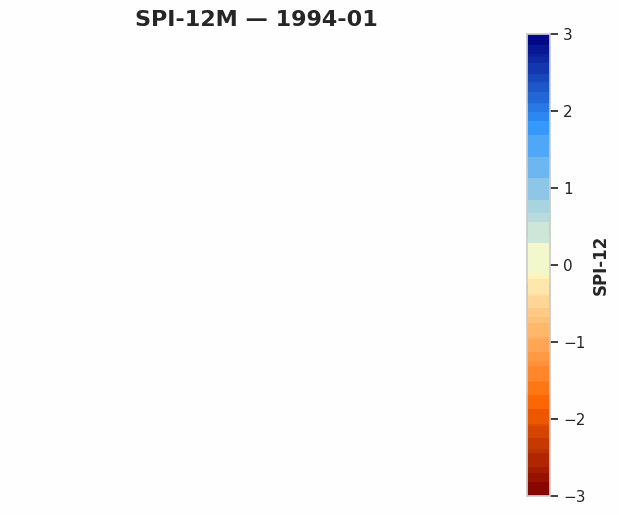

In [47]:
from IPython.display import Image
Image(filename="spi12_anim.gif")